# Notebook 5 — AC Adaptation and Equity

This notebook builds and analyses air-conditioning (AC) adaptation scenarios for the selected city (`SLUG` / `CITY`) on the CLIMADA reference grid. It disaggregates city-level AC penetration scenarios to local postal areas (CAPs), applies a lowest income “catch-up” AC policy, and quantifies the impact of AC expansion on heat-related mortality, including equity and vulnerability dimensions.

**What this notebook does**

1. **Setup and inputs**
   - Load city configuration and paths (`configs/<slug>.yml`).
   - Load reference grid, city mask, FUA boundary, municipality and CAP polygons.
   - Load age- and population grids (baseline and future demographic scenarios).
   - Load CLIMADA heat hazard (daily temperature), age-specific impact functions, and AC efficacy scenarios.
   - Optionally load a social vulnerability index (SVI) grid.

2. **Current & future AC coverage**
   - Read NUTS-level AC penetration scenarios (e.g. SSP1/2/3/5) for the city.
   - Build city-level AC targets by year (e.g. 2030/2040/2050).
   - Disaggregate AC coverage to CAPs using income data and a logistic curve:
     - richer CAPs → higher AC coverage,
     - bounded between configurable min/max,
     - population-weighted city mean matches the NUTS target.
   - Map CAP-level AC shares to the CLIMADA grid and run QA checks.

3. **AC policy scenario (“catch-up”)**
   - Rank CAPs by income using grid population as weights (2030 baseline population, no year-specific pop arrays i.e the selection happens once, not recaclculated each year, same target_idsused for all years) = **static** policy..
   - Select the poorest X% of population (e.g. 50%) by CAP income rank.
   - Enforce a minimum AC coverage level (e.g. 70%) in targeted CAPs, respecting global min/max bounds.
   - Produce baseline vs policy AC coverage maps by CAP and by municipality for each AC year.
   - One targeting decision (2030), that we apply consistently over time, and then evaluate how well it performs as demographics change. 

4. **Municipality-level aggregation (for CBA)**
   - Aggregate baseline and policy AC coverage to Municipi using population weights.
   - Export municipality-by-year AC coverage tables for use in cost–benefit analysis.

5. **Heat-mortality impacts with AC**
   - Apply age-specific mortality dose–response functions to the daily heat hazard.
   - For each year and scenario, compute annual heat deaths under:
     - **no AC / generic**,  
     - **current AC baseline**,  
     - **AC catch-up policy**.
   - Report avoided deaths at city and municipality level, and by age group.
   - Save summary tables (e.g. `annual_heat_deaths_climada_avoided_AC_<city>.csv`) and run metadata.

6. **Vulnerability-stratified analysis**
   - Use the SVI grid to define both:
     - exposure-based SVI quintiles, and
     - population-weighted SVI quintiles (each ≈ 20% of population).
   - For each quintile and year, compute:
     - deaths per 100k under baseline and policy AC,
     - avoided deaths when moving from baseline to policy,
     - Q5/Q1 disparity ratios.
   - Show how AC expansion reduces overall mortality and modestly narrows vulnerability-related inequalities.

7. **Marginal heat deaths per +1 °C (for NB8)**
   - Create a perturbed hazard with a uniform +ΔT (e.g. +1 °C) shift in daily temperatures.
   - For each year and AC scenario, compute additional annual heat deaths per +1 °C.
   - Provide inputs for downstream analysis of how AC moderates the mortality impact of future warming.

**Main outputs (in `OUT/` and `INT/`)**

- CAP- and municipality-level AC coverage maps and CSVs for each AC year.
- City- and municipality-level avoided deaths (baseline vs policy), including “avoided deaths per pp of AC uplift”.
- Age-stratified avoided deaths tables and AC run metadata.
- Vulnerability-stratified deaths and avoided-deaths tables (row-based and pop-weighted SVI quintiles) and figures.
- Marginal deaths per +1 °C statistics to be used in later notebooks.

In [69]:
import os
os.environ["CITY"] = "rome"   # pick the city here

In [70]:
# generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim


In [71]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: rome Rome
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/gviRome/gvi_Rome.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/CoolingEff/outer_2_wbgt_max.csv


**Loading from before**

In [72]:
from pathlib import Path
import json, numpy as np, geopandas as gpd, rasterio as rio

tmpl_path = INT / "template_ref.tif"
mask_tif  = INT / "city_mask.tif"
fua_gp    = OUT / f"{SLUG}_fua.gpkg"

age_npz = INT / f"age_on_ref_{SLUG}.npz"
if not age_npz.exists():
    age_npz = INT / "age_on_ref.npz"

pop_npz = INT / f"pop_on_ref_{SLUG}.npz"
if not pop_npz.exists():
    pop_npz = INT / "pop_on_ref.npz"

AUX_NPZ = INT / f"{SLUG}_veg_aux_arrays.npz"
muni_tif_new = OUT / f"{SLUG}_muni_on_ref.tif"
muni_tif_legacy = OUT / "muni_on_ref.tif"

# Template/meta + mask 
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

# Age / population rasters on ref grid 
agez = np.load(age_npz)
age_on_ref = {
    "<15":   agez["lt15"].astype("float32"),
    "15-64": agez["a15_64"].astype("float32"),
    "65+":   agez["g65"].astype("float32"),
}
pop_on_ref = np.load(pop_npz)["pop"].astype("float32")

# Keep a copy of the baseline (2030, scenario-neutral) grids
age_on_ref_base = {k: v.copy() for k, v in age_on_ref.items()}
pop_on_ref_base = pop_on_ref.copy()

# FUA vector 
if not fua_gp.exists():
    raise FileNotFoundError(f"Missing FUA GeoPackage: {fua_gp} — re-run Notebook 2 for {CITY}.")
fua = gpd.read_file(fua_gp, layer="fua")
fua_4326 = fua.to_crs("EPSG:4326")

# Footprint / analysis masks 
ref_data = np.where(CITY_MASK, 0.0, np.nan).astype("float32")  # same shape as ref grid
HAZ_MASK = np.isfinite(ref_data)

# Not strictly required for AC, but useful for later plots/joins
if AUX_NPZ.exists():
    aux = np.load(AUX_NPZ)
    muni_on_ref = aux.get("muni_on_ref", None)
    lcz_on_ref  = aux.get("lcz_on_ref",  None)
    gvi_on_ref  = aux.get("gvi_on_ref",  None)
    dGVI_points = aux.get("dGVI_points", None)
    dT_month_ref= aux.get("dT_month_ref", None)

# If AUX bundle missing, try muni label from GeoTIFF saved in NB5
if 'muni_on_ref' not in globals() or muni_on_ref is None:
    if muni_tif_new.exists() or muni_tif_legacy.exists():
        with rio.open(muni_tif_new if muni_tif_new.exists() else muni_tif_legacy) as src:
            muni_on_ref = src.read(1).astype("int32")  # 0 = outside
    else:
        muni_on_ref = None

print(f"Ref grid: {(HGT, WDT)} | CRS: {ref_meta['crs']}")
print("CITY_MASK true pixels:", int(CITY_MASK.sum()))
print("Pop sum on ref:", float(np.nansum(pop_on_ref)))
print("AUX loaded:", AUX_NPZ.exists(), "| muni_on_ref set:", muni_on_ref is not None)

Ref grid: (301, 301) | CRS: EPSG:3035
CITY_MASK true pixels: 77915
Pop sum on ref: 2548153.5
AUX loaded: True | muni_on_ref set: True


In [73]:
import geopandas as gpd, rasterio as rio, pandas as pd, numpy as np

# paths
gpkg_path = OUT / f"{SLUG}_regions.gpkg"
tif_path  = OUT / f"{SLUG}_muni_on_ref.tif"
lut_path  = OUT / f"{SLUG}_muni_lut.csv"

# loading vectors
regions = gpd.read_file(gpkg_path, layer="regions").to_crs("EPSG:4326")
muni    = gpd.read_file(gpkg_path, layer="muni").to_crs("EPSG:4326")
lut     = pd.read_csv(lut_path)

# loading label grid (aligned to T2M ref grid)
with rio.open(tif_path) as src:
    assert src.crs == ref_meta["crs"] and src.transform == ref_meta["transform"], "Grid mismatch."
    muni_on_ref = src.read(1).astype("int32")

print("Loaded regions:", len(regions), "polygons; muni_on_ref shape:", muni_on_ref.shape)

valid_ids = np.unique(muni_on_ref[muni_on_ref > 0])
print("Unique muni IDs (excluding 0):", len(valid_ids))

Loaded regions: 16 polygons; muni_on_ref shape: (301, 301)
Unique muni IDs (excluding 0): 15


In [74]:
from climada.hazard import Hazard
from climada.entity import Exposures

from pathlib import Path

def _pick_existing(cands, what):
    """Return the first existing path in cands, or raise a clear error."""
    for p in cands:
        if p and Path(p).exists():
            return Path(p)
    tried = "\n".join(str(Path(p)) for p in cands if p)
    raise FileNotFoundError(f"Missing {what}. Tried:\n{tried}")

# loading hazard and exposure
haz_candidates = [
    paths.get("hazard_h5"),
    INT / f"hazard_T2M_daily_{SLUG}.h5",
    OUT / f"hazard_T2M_daily_{SLUG}.h5",
    INT / f"hazard_HEAT_{SLUG}.h5",
    INT / f"{SLUG}_hazard_HEAT.h5",
    INT / "hazard_HEAT.h5",
    OUT / f"hazard_HEAT_{SLUG}.h5",
    OUT / f"{SLUG}_hazard_HEAT.h5",
]

haz_path = _pick_existing(haz_candidates, "hazard .h5")

# Read via CLIMADA
try:
    H = Hazard.from_hdf5(haz_path)
except Exception:
    H = Hazard(); H.read_hdf5(haz_path)

import numpy as np

n_ev = H.intensity.shape[0]

# hazard type/units
if not getattr(H, "haz_type", None):
    H.haz_type = "T2M"                      # daily mean temperature
if not getattr(H, "units", None):
    H.units = "degC (daily mean)"

# event ids / dates: keep if present, otherwise try to reconstruct from CSV
if not hasattr(H, "event_id") or len(getattr(H, "event_id", [])) != n_ev:
    try:
        import pandas as pd
        ev = pd.read_csv(INT / f"hazard_T2M_daily_events_{SLUG}.csv")
        if len(ev) == n_ev:
            H.event_id = ev["event_id"].to_numpy(int)
        else:
            H.event_id = np.arange(n_ev, dtype=int)
    except Exception:
        H.event_id = np.arange(n_ev, dtype=int)

if not hasattr(H, "date") or len(getattr(H, "date", [])) != n_ev:
    try:
        import pandas as pd
        ev = pd.read_csv(INT / f"hazard_T2M_daily_events_{SLUG}.csv",
                         parse_dates=["date"])
        if len(ev) == n_ev:
            H.date = ev["date"].to_numpy("datetime64[ns]")
    except Exception:
        pass

# frequency: each event is one day
# we later sum explicitly over days
if not hasattr(H, "frequency") or len(getattr(H, "frequency", [])) != n_ev:
    H.frequency = np.ones(n_ev, dtype=float)
if not getattr(H, "frequency_unit", None):
    H.frequency_unit = "1/day"

# event_name 
if not hasattr(H, "event_name") or len(getattr(H, "event_name", [])) != n_ev:
    try:
        H.event_name = np.array(
            [f"T2M_{str(np.datetime_as_string(d, unit='D'))}" for d in H.date],
            dtype=object
        )
    except Exception:
        H.event_name = np.array([f"T2M_{i:06d}" for i in range(n_ev)],
                                dtype=object)

# strict grid check unchanged
n_cells = H.intensity.shape[-1]
assert n_cells == HGT * WDT, (
    f"[{SLUG}] grid mismatch: hazard cells={n_cells} vs ref={HGT*WDT}. "
    "Rebuild hazard on this ref grid."
)

In [75]:
# age-specific impact functions "frozen" in NB4 
import json, numpy as np
from pathlib import Path

def _pick_existing(cands, what):
    for p in cands:
        if p and Path(p).exists():
            return Path(p)
    tried = "\n".join(str(Path(p)) for p in cands if p)
    raise FileNotFoundError(f"Missing {what}. Tried:\n{tried}")

froze_candidates = [
    paths.get("if_freeze_json") if "paths" in globals() else None,
    Path(INT) / f"if_curves_frozen_{SLUG}.json",  # preferred
    Path(INT) / "if_curves_frozen.json",         
    Path(OUT) / f"if_curves_frozen_{SLUG}.json", 
]
froze_path = _pick_existing(froze_candidates, "frozen impact-function JSON")

with open(froze_path, "r") as fh:
    IF_FREEZE = json.load(fh)

class _IF:
    def __init__(self, intensity, mdd, name=None, fid=None):
        self.intensity = np.asarray(intensity, float)
        self.mdd       = np.asarray(mdd, float)
        self.name      = name
        self.id        = fid

required = {"intensity", "mdd"}
for k, v in IF_FREEZE.items():
    missing = required - v.keys()
    if missing:
        raise ValueError(f"IF '{k}' missing fields: {missing}")

age_ifs = {
    k: _IF(v["intensity"], v["mdd"], name=v.get("name"), fid=v.get("id"))
    for k, v in IF_FREEZE.items()
}
print("Loaded frozen IFs:",
      {k: (age_ifs[k].name, len(age_ifs[k].intensity)) for k in age_ifs})

Loaded frozen IFs: {'<15': ('<15', 81), '15-64': ('15–64', 81), '65+': ('65+', 81)}


In [76]:
# age rasters on the reference grid (saved in NB3) 
import numpy as np
from pathlib import Path

_age_tagged = INT / f"age_on_ref_{SLUG}.npz"
age_npz = _age_tagged if _age_tagged.exists() else (INT / "age_on_ref.npz")

agez = np.load(age_npz)
age_on_ref = {
    "<15":   agez["lt15"].astype("float32"),
    "15-64": agez["a15_64"].astype("float32"),
    "65+":   agez["g65"].astype("float32"),
}

In [78]:
# pick which scenario we want for efficacy (cf YAML config file)
EFF_SCENARIO = os.environ.get("EFF_SCENARIO", "high")

scenarios = cfg.get("efficacy_scenarios", {}) or {}

if EFF_SCENARIO in scenarios:
    EFF_BUCKETS = {k: float(v) for k, v in scenarios[EFF_SCENARIO].items()}
    # keep a default too 
    EFF_DEFAULT = float(cfg.get("efficacy", {}).get("default", 0.30))
else:
    # fallback to the existing single-map behavior
    eff_map = cfg.get("efficacy", {}) or {}
    EFF_DEFAULT = float(eff_map.get("default", 0.30))
    EFF_BUCKETS = {k: float(v) for k, v in eff_map.items() if k != "default"}

# ensure all age buckets exist 
for k in ["<15", "15-64", "65+"]:
    EFF_BUCKETS.setdefault(k, EFF_DEFAULT)

print("EFF_SCENARIO:", EFF_SCENARIO)
print("EFF_BUCKETS:", EFF_BUCKETS, "| default:", EFF_DEFAULT)

EFF_SCENARIO: high
EFF_BUCKETS: {'<15': 0.3, '15-64': 0.4, '65+': 0.55} | default: 0.3


In [79]:
import json

expo_manifest_path = INT / "exposure_manifest.json"

AGE_GRID = {}
POP_GRID = {}

if expo_manifest_path.exists():
    with open(expo_manifest_path) as f:
        expo_manifest = json.load(f)

    scen_dict = expo_manifest.get("scenarios", {})

    # picking demographic scenario: from YAML if present, else fall back
    # to the SSP used for AC (if it matches), else first scenario
    EXP_SCENARIO = cfg.get("exp_scenario")
    if not EXP_SCENARIO:
        ac_cfg = cfg.get("ac", {})
        ssp = ac_cfg.get("ssp", None)
        if ssp is not None:
            cand = f"ssp{ssp}".lower()
            if cand in scen_dict:
                EXP_SCENARIO = cand

    if not EXP_SCENARIO or EXP_SCENARIO not in scen_dict:
        # Fallback: just take the first key
        EXP_SCENARIO = sorted(scen_dict.keys())[0]

    print("Using demographic scenario for exposure:", EXP_SCENARIO)

    for year_str, rec in scen_dict[EXP_SCENARIO].items():
        y = int(year_str)

        ages_future_npz = np.load(rec["age_npz"])
        AGE_GRID[y] = {
            "<15":   ages_future_npz["lt15"].astype("float32"),
            "15-64": ages_future_npz["a15_64"].astype("float32"),
            "65+":   ages_future_npz["g65"].astype("float32"),
        }

        pop_future_npz = np.load(rec["pop_npz"])
        POP_GRID[y] = pop_future_npz["pop"].astype("float32")

else:
    print(" exposure_manifest.json not found in INT – will reuse 2030 baseline age/pop for all years.")

Using demographic scenario for exposure: SSP2


## Current AC Penetration at the CAP Level

**Loading data : income and AC penetration**

No pixel netCDF anymore, NUTS csv!

In [80]:
import pandas as pd
import re

def load_ac_city_by_year(cfg, P):
    """
    Returns dict like {2030: penetration, ...} using cfg['ac'].
    Scenario is taken as an integer from cfg['ac']['ssp'] and matched
    to the integer part of the CSV 'Scenario' column (values like 1,2,3,5 or SSP1, SSP2, ...).
    """
    ac_cfg = cfg["ac"]

    # scenario selector: numeric
    ssp_choice = int(ac_cfg.get("ssp", 2))  # 1,2,3,5
    print(f"[AC penetration] Using scenario ssp = {ssp_choice} (from cfg['ac']['ssp'])")

    # load CSV 
    f = P(ac_cfg["penetration_file"])
    df = pd.read_csv(f)

    cols = ac_cfg.get("nuts_columns", {})
    col_id   = cols.get("id", "NUTS_ID")
    col_scen = cols.get("scenario", "Scenario")
    col_year = cols.get("year", "year")
    col_val  = cols.get("value", "value")

    nuts_id = ac_cfg["nuts_id"]
    years   = [int(y) for y in ac_cfg.get("years", [2030, 2040, 2050])]

    # normalise Scenario column to an integer 
    def _scenario_to_int(x):
        s = str(x)
        m = re.search(r"(\d+)", s)  # handles "2" and "SSP2"
        return int(m.group(1)) if m else None

    df = df.copy()
    df["_scenario_int"] = df[col_scen].map(_scenario_to_int)
    df[col_year] = pd.to_numeric(df[col_year], errors="coerce")
    df[col_val]  = pd.to_numeric(df[col_val], errors="coerce")

    # filter by NUTS + scenario
    sub = df[
        (df[col_id].astype(str) == str(nuts_id)) &
        (df["_scenario_int"] == ssp_choice)
    ].dropna(subset=[col_year, col_val])

    if sub.empty:
        raise ValueError(
            f"No AC penetration rows for {col_id}={nuts_id} and Scenario={ssp_choice} in {f}"
        )

    # build dict {year: penetration} 
    ac_city_by_year = {}
    for y in years:
        hit = sub.loc[sub[col_year].astype(int) == y, col_val]
        if hit.empty:
            raise ValueError(
                f"Missing year {y} for NUTS_ID={nuts_id}, Scenario={ssp_choice}"
            )
        ac_city_by_year[y] = float(hit.iloc[0])

    return ac_city_by_year

# usage
ac_city_by_year = load_ac_city_by_year(cfg, P)
YEARS_AC = sorted(ac_city_by_year.keys())
year_to_index = {y: i for i, y in enumerate(YEARS_AC)}

print("AC targets (penetration):", ac_city_by_year)
print("YEARS_AC:", YEARS_AC)

[AC penetration] Using scenario ssp = 2 (from cfg['ac']['ssp'])
AC targets (penetration): {2030: 0.705737888813019, 2040: 0.740042567253113, 2050: 0.740042567253113}
YEARS_AC: [2030, 2040, 2050]


In [81]:
for y in YEARS_AC:
    print(y, ac_city_by_year[y])

2030 0.705737888813019
2040 0.740042567253113
2050 0.740042567253113


In [82]:
import pandas as pd, json

# csv file
ac_targets_csv = INT / f"ac_city_targets_{SLUG}.csv"
pd.DataFrame({
    "year": YEARS_AC,
    "ac_share": [float(ac_city_by_year[y]) for y in YEARS_AC],
}).to_csv(ac_targets_csv, index=False)

# metadata 
ac_cfg = cfg.get("ac", {})
cols = ac_cfg.get("nuts_columns", {})
ssp_choice = int(ac_cfg.get("ssp", 2))

ac_targets_meta = {
    "nuts_id": ac_cfg.get("nuts_id", None),
    "scenario": ssp_choice,  # integer 1/2/3/5
    "penetration_file": str(P(ac_cfg.get("penetration_file", ""))),
    "columns": {
        "id": cols.get("id", "NUTS_ID"),
        "scenario": cols.get("scenario", "Scenario"),
        "year": cols.get("year", "year"),
        "value": cols.get("value", "value"),
    },
}
with open(INT / f"ac_city_targets_meta_{SLUG}.json", "w") as f:
    json.dump(ac_targets_meta, f, indent=2)

print("✓ Wrote:", ac_targets_csv)

✓ Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_city_targets_rome.csv


> **Explanation of the following steps:**
> - We only know the Rome AC penetration share
> - We have income data at the CAP level
    > - We want a map across CAP where:
    > - Higher AC in richer CAPS and lower in poorer caps
    > - stays in plausible bounds
    > - averages back to 0.724 when we weight by ppl 

**Income Dataset**

In [83]:
import re
from pathlib import Path

files = cfg.get("files", {})
rel = files["income_csv"]                         
rel = re.sub(r'(^|/)[Ii]ncome/', r'\1income/', rel)  

income_csv = P(rel)                              
assert Path(income_csv).exists(), f"Missing income CSV: {income_csv}"
print("Income CSV →", income_csv)

Income CSV → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/income/Redditi_e_principali_variabili_IRPEF_su_base_subcom.csv


In [84]:
# normalising a CAP to a 5-digit string with 00 before or na if missing or invalid
def to_cap5(s):
    s = "" if pd.isna(s) else str(s)
    s = re.sub(r"\D","", s)
    return np.nan if not s else s.zfill(5)[-5:]

def _norm(s):
    return str(s).upper()

In [85]:
# columns for the Italian IRPEF file (same for Rome/Genova) 
COL_CITY   = "Denominazione Comune"
COL_CAP    = "CAP"
COL_TAXP   = "Numero contribuenti"
COL_TOTINC = "Reddito complessivo - Ammontare in euro"

In [86]:
# aliases from YAML 
aliases = [_norm(cfg.get("city_name", SLUG))]
aliases += [_norm(a) for a in cfg.get("cooling_city_aliases", [])]
aliases = list(dict.fromkeys(aliases))  

In [87]:
# load and city-filter
df = pd.read_csv(income_csv, sep=None, engine="python")
city_col = df[COL_CITY].astype(str).map(_norm)
mask = pd.Series(False, index=df.index)
for a in aliases:
    mask |= city_col.str.contains(a, na=False)

inc_city = df[mask].copy()

In [88]:
import re

# clean and compute 
inc_city[COL_TAXP]   = pd.to_numeric(inc_city[COL_TAXP],   errors="coerce")
inc_city[COL_TOTINC] = pd.to_numeric(inc_city[COL_TOTINC], errors="coerce")
inc_city["cap5"]     = inc_city[COL_CAP].map(to_cap5)

inc_city = inc_city.dropna(subset=["cap5", COL_TAXP, COL_TOTINC])
inc_city = inc_city[inc_city[COL_TAXP] > 0].copy()

inc_city["inc_mean"] = inc_city[COL_TOTINC] / inc_city[COL_TAXP]
lo, hi = inc_city["inc_mean"].quantile([0.01, 0.99])
inc_city["inc_w"] = inc_city["inc_mean"].clip(lo, hi)

print(f"[{SLUG}] CAP rows: {len(inc_city)} | unique CAP: {inc_city['cap5'].nunique()}")
print(f"[{SLUG}] Taxpayers total: {int(inc_city[COL_TAXP].sum())}")
city_mean = inc_city[COL_TOTINC].sum() / inc_city[COL_TAXP].sum()
print(f"[{SLUG}] City per-taxpayer mean (EUR): {city_mean:,.0f}")

[rome] CAP rows: 72 | unique CAP: 72
[rome] Taxpayers total: 1951864
[rome] City per-taxpayer mean (EUR): 30,702


**CAP polygons to CLIMADA grid**

In [89]:
files = cfg.get("files", {})
p_cap_shp = P(files.get("cap_shp", "CAPZONE/CAPZONE.shp"))
assert p_cap_shp.exists(), f"Missing CAP shapefile: {p_cap_shp}"

In [90]:
# CAP polygons to CLIMADA grid labels
import numpy as np
import geopandas as gpd
from shapely import set_precision
from rasterio.features import rasterize

def pick_col(cols, *cands):
    low = {c.lower(): c for c in cols}
    for cand in cands:
        for k, v in low.items():
            if cand.lower() in k:
                return v
    raise KeyError(f"None of {cands} found in columns: {list(cols)}")

# loading CAP shapes
cap = gpd.read_file(p_cap_shp)
cap = cap.set_crs("EPSG:4326", allow_override=True) if cap.crs is None else cap.to_crs("EPSG:4326")

cap_col = pick_col(
    cap.columns,
    "cap", "CAP", "codice", "cod_cap", "cap_5", "cap5", "zip", "postal", "postcode"
)
cap["cap5"] = cap[cap_col].map(to_cap5)
cap = cap[cap["cap5"].notna()].copy()

# fix geometries and precision
cap = cap.set_geometry(cap.geometry.buffer(0))
cap = cap[~cap.geometry.is_empty]
cap = cap.set_geometry(set_precision(cap.geometry, grid_size=1e-9))

cap_4326 = (cap[["cap5","geometry"]]
            .dissolve(by="cap5", as_index=False))

# clipping to FUA 
fua_4326 = fua.to_crs("EPSG:4326")[["geometry"]]
cap_4326 = gpd.overlay(cap_4326, fua_4326, how="intersection")
cap_4326 = cap_4326[~cap_4326.geometry.is_empty].reset_index(drop=True)

# stable IDs + project to ref grid CRS 
cap_4326["cap_id"] = np.arange(1, len(cap_4326)+1, dtype=int)
cap_ref = cap_4326.to_crs(ref_meta["crs"])

# rasterize to the ref grid 
shapes = [(geom, int(cid)) for geom, cid in zip(cap_ref.geometry, cap_ref["cap_id"])]
cap_on_ref = rasterize(
    shapes=shapes,
    out_shape=ref_data.shape,
    transform=ref_meta["transform"],
    fill=0, dtype="int32",
    all_touched=False
)

# checks 
haz_mask = np.isfinite(ref_data)
u_ids = np.unique(cap_on_ref[haz_mask])
print(f"[{SLUG}] CAP pixels in hazard: {int(((cap_on_ref>0)&haz_mask).sum()):,}")
print(f"[{SLUG}] Unique CAP IDs on grid: {u_ids[u_ids>0].size} / {len(cap_ref)}")

# lookups for later 
cap_id_to_cap5 = dict(zip(cap_ref["cap_id"].astype(int), cap_ref["cap5"]))
cap5_to_id     = {v:k for k,v in cap_id_to_cap5.items()}
cap_lut        = {str(row.cap5): int(row.cap_id) for _, row in cap_ref.iterrows()}

[rome] CAP pixels in hazard: 77,915
[rome] Unique CAP IDs on grid: 81 / 118


In [91]:
# new mask
CAP_PIX   = CITY_MASK & (cap_on_ref  > 0) # pixels labeled by CAP

In [92]:
# Only the income table from CSV (no population here)
inc_agg = (inc_city.groupby("cap5", as_index=False)
           .agg(taxp=(COL_TAXP, "sum"),
                inc_sum=(COL_TOTINC, "sum")))
inc_agg["inc_mean"] = inc_agg["inc_sum"] / inc_agg["taxp"]

canon = cap_ref[["cap_id","cap5"]].drop_duplicates().copy()
canon["cap5"] = canon["cap5"].astype(str).str.strip().str.zfill(5)

df_capgrid = pd.DataFrame({
    "cap_id": cap_on_ref[CAP_PIX].ravel().astype(int),
    "pop":    pop_on_ref[CAP_PIX].ravel().astype(float),
})
df_capgrid = df_capgrid[df_capgrid["cap_id"] > 0]
cap_pop_grid = (df_capgrid.groupby("cap_id", as_index=False)["pop"]
                .sum().rename(columns={"pop": "pop_cap"}))

cap_stats = (canon
    .merge(cap_pop_grid, on="cap_id", how="left")
    .merge(inc_agg[["cap5","taxp","inc_sum","inc_mean"]], on="cap5", how="left")
    .fillna({"pop_cap": 0.0})
)

# impute inc_mean where we have population but missing CSV entry
city_mean_inc = float(inc_city[COL_TOTINC].sum() / inc_city[COL_TAXP].sum())
need_inc = (cap_stats["pop_cap"] > 0) & (~cap_stats["inc_mean"].notna())
cap_stats.loc[need_inc, "inc_mean"] = city_mean_inc

In [93]:
# pop-weighted percentile rank of CAP income 
def weighted_percentile_rank(values, weights):
    # sorting by values (ascending: poorer first)
    order = np.argsort(values)
    v = np.asarray(values)[order]
    w = np.asarray(weights, dtype=float)[order]
    if w.sum() <= 0:
        return np.full_like(v, 0.5, dtype=float)
    # midpoint cumulative share: places each observation at the center of its mass
    c = np.cumsum(w) - 0.5*w
    p = c / w.sum()
    out = np.empty_like(p, dtype=float)
    out[order] = p
    return out
# function returns 0-1 rank for each value using weights as population
# mass: Lower income -> lower rank (poorer), 'midpoint' convention so identical values land around their weighted middle. If total weight <= 0, return 0.5 for all 

In [94]:
nz = cap_stats["pop_cap"] > 0
if nz.sum() >= 10:
    lo, hi = cap_stats.loc[nz, "inc_mean"].quantile([0.01, 0.99])
else:
    lo, hi = cap_stats["inc_mean"].min(), cap_stats["inc_mean"].max()
cap_stats["inc_rank_base"] = cap_stats["inc_mean"].clip(lo, hi)

# ranking poorer to richer in [0,1], weighted by pop (WorldPop)
# Pop-weighted percentile rank (poorer : lower rank), using grid pop as weights
mask = nz & np.isfinite(cap_stats["inc_rank_base"])
p = np.full(len(cap_stats), np.nan, float)
p[mask] = weighted_percentile_rank(
    cap_stats.loc[mask, "inc_rank_base"].to_numpy(),
    cap_stats.loc[mask, "pop_cap"].to_numpy()
)
cap_stats["p_inc"] = np.clip(p, 1e-3, 1-1e-3)

# QA: cap_stats vs 2030 grid
grid_pop_2030 = float(np.nansum(POP_GRID[2030][CAP_PIX]))
stats_pop_2030 = float(cap_stats["pop_cap"].sum())
print(f"2030 (cap_stats vs POP_GRID[2030]): {stats_pop_2030/grid_pop_2030:.6f}")

# QA (city-level CAP totals vs grid POP_GRID, using the exposure/pop for each year)
print("QA – CAP pop totals vs grid POP_GRID, by year (CAP_PIX only)")

for year, pop_grid in sorted(POP_GRID.items()):
    # total pop on the grid, restricted to CAP pixels
    grid_pop = float(np.nansum(pop_grid[CAP_PIX]))

    # recompute CAP totals from the same year-specific grid
    df_capgrid_y = pd.DataFrame({
        "cap_id": cap_on_ref[CAP_PIX].ravel().astype(int),
        "pop":    pop_grid[CAP_PIX].ravel().astype(float),
    })
    df_capgrid_y = df_capgrid_y[df_capgrid_y["cap_id"] > 0]

    cap_pop_grid_y = (
        df_capgrid_y
        .groupby("cap_id", as_index=False)["pop"]
        .sum()
    )

    stats_pop = float(cap_pop_grid_y["pop"].sum())
    print(f"  {year}: CAP sum / grid = {stats_pop/grid_pop:.6f}")

2030 (cap_stats vs POP_GRID[2030]): 1.000000
QA – CAP pop totals vs grid POP_GRID, by year (CAP_PIX only)
  2030: CAP sum / grid = 1.000000
  2040: CAP sum / grid = 1.000000
  2050: CAP sum / grid = 1.000000


In [95]:
import numpy as np

# make years consistent 
YEARS_AC = [int(y) for y in YEARS_AC]
ac_city_by_year = {int(k): float(v) for k, v in ac_city_by_year.items()}

CITY_LABEL = cfg.get("city_name", globals().get("CITY", SLUG))

# inputs for calibration 
valid = (cap_stats["pop_cap"] > 0) & np.isfinite(cap_stats["p_inc"])
if not valid.any():
    raise RuntimeError("No valid CAP rows (require pop_cap>0 and finite p_inc).")

p_inc = cap_stats.loc[valid, "p_inc"].to_numpy(float)
w     = cap_stats.loc[valid, "pop_cap"].to_numpy(float)

ac_cfg = cfg.get("ac", {})
ac_min = float(ac_cfg.get("ac_min", 0.05))
ac_max = float(ac_cfg.get("ac_max", 0.98))
s      = float(ac_cfg.get("rank_slope", 2.2))

sig        = 1.0 / (1.0 + np.exp(-s * (p_inc - 0.5)))
base_acraw = ac_min + (ac_max - ac_min) * sig

ac_cap_by_year = {}
k_star_by_year = {}

def avg_after_clip(k: float, target_shape: np.ndarray) -> float:
    x = np.clip(ac_min + k * (target_shape - ac_min), ac_min, ac_max)
    return float(np.average(x, weights=w)) if w.sum() > 0 else float(x.mean())

# building CAP-level AC for each year 
for y in YEARS_AC:
    if y not in ac_city_by_year:
        raise KeyError(f"Year {y} missing in ac_city_by_year. Have: {sorted(ac_city_by_year)}")

    target = float(ac_city_by_year[y])
    if target > 1.0:
        target /= 100.0
    target = float(np.clip(target, 0.0, 1.0))

    lo_mean = avg_after_clip(0.0, base_acraw)
    hi_mean = avg_after_clip(1e6, base_acraw)
    if not (lo_mean - 1e-9 <= target <= hi_mean + 1e-9):
        print(f"[warn] {y}: target {target:.3f} outside [{lo_mean:.3f}, {hi_mean:.3f}]")

    k_lo, k_hi = 0.0, 1e6
    for _ in range(60):
        k_mid = 0.5 * (k_lo + k_hi)
        if avg_after_clip(k_mid, base_acraw) < target:
            k_lo = k_mid
        else:
            k_hi = k_mid
    k_star = 0.5 * (k_lo + k_hi)

    x = np.clip(ac_min + k_star * (base_acraw - ac_min), ac_min, ac_max)

    ac_vec = np.full(len(cap_stats), np.nan, dtype=float)
    ac_vec[valid.to_numpy()] = x
    ac_cap_by_year[y] = ac_vec
    k_star_by_year[y] = k_star

    achieved = float(np.average(x, weights=w))
    print(f"[{CITY_LABEL}] Year {y}: target={target:.3f}, achieved={achieved:.3f}, k*={k_star:.4g}")

# compatibility column (anchor to last year in YEARS_AC)
cap_stats["ac_cap_baseline"] = ac_cap_by_year[YEARS_AC[-1]]

# now building grid maps 
year_to_index = {y: idx for idx, y in enumerate(YEARS_AC)}
n_years = len(YEARS_AC)

max_cap_id = int(cap_stats["cap_id"].max())
cap_ids    = cap_stats["cap_id"].astype(int).to_numpy()

coverage_base_3d = np.full((n_years, HGT, WDT), np.nan, dtype="float32")

for y in YEARS_AC:
    ac_by_id = np.full(max_cap_id + 1, np.nan, dtype=float)
    ac_by_id[cap_ids] = ac_cap_by_year[y]

    grid = ac_by_id[cap_on_ref]
    grid[~CITY_MASK] = np.nan
    coverage_base_3d[year_to_index[y]] = grid.astype("float32")

coverage_base = coverage_base_3d[year_to_index[YEARS_AC[-1]]]

[Rome] Year 2030: target=0.706, achieved=0.706, k*=1.417
[Rome] Year 2040: target=0.740, achieved=0.740, k*=1.511
[Rome] Year 2050: target=0.740, achieved=0.740, k*=1.511


In [96]:
# building simple uniform maps for each year 
year_to_index = {y: idx for idx, y in enumerate(YEARS_AC)}
n_years = len(YEARS_AC)

max_cap_id = int(cap_stats["cap_id"].max())
cap_ids    = cap_stats["cap_id"].astype(int).to_numpy()

coverage_base_3d = np.full((n_years, HGT, WDT), np.nan, dtype="float32")

for y in YEARS_AC:
    k = year_to_index[y]

    ac_by_id = np.full(max_cap_id + 1, np.nan, dtype=float)
    ac_by_id[cap_ids] = ac_cap_by_year[y]

    grid = ac_by_id[cap_on_ref]      # CAP to grid
    grid[~CITY_MASK] = np.nan

    coverage_base_3d[k] = grid.astype("float32")

coverage_base = coverage_base_3d[YEARS_AC.index(2050)]

In [97]:
def make_cap_sub_for_year(y):
    """CAP-level table for year y, with AC share from ac_cap_by_year[y]."""
    vec = ac_cap_by_year[y]  # length = len(cap_stats)
    tmp = cap_stats.copy()
    tmp["ac_cap_year"] = vec

    cap_sub_y = tmp.loc[
        (tmp["pop_cap"] > 0)
        & np.isfinite(tmp["inc_mean"])
        & np.isfinite(tmp["ac_cap_year"]),
        ["cap5", "inc_mean", "inc_rank_base", "p_inc", "ac_cap_year", "pop_cap"]
    ].copy()
    return cap_sub_y


=== QA for year 2030 ===
Poorest CAPs (by clipped income rank): expect low p_inc & low AC


,cap5,inc_mean,inc_rank_base,p_inc,ac_cap_year,pop_cap
40,00119,"16,405.440","19,472.391",0.003,0.381,"17,621.181"
52,00133,"20,239.128","20,239.128",0.027,0.394,"103,728.387"
51,00132,"20,526.122","20,526.122",0.049,0.407,"8,590.451"
87,00172,"21,838.697","21,838.697",0.058,0.412,"35,544.091"
47,00126,"21,879.120","21,879.120",0.072,0.420,"37,363.317"
86,00171,"21,986.438","21,986.438",0.084,0.427,"20,995.874"
85,00169,"22,324.881","22,324.881",0.095,0.433,"34,966.397"
102,00188,"22,460.978","22,460.978",0.104,0.439,"11,587.981"



Richest CAPs (by clipped income rank): expect high p_inc & high AC


,cap5,inc_mean,inc_rank_base,p_inc,ac_cap_year,pop_cap
109,00197,"73,978.616","70,013.808",0.994,0.980,"28,695.673"
101,00187,"69,022.606","69,022.606",0.985,0.980,"20,959.327"
110,00198,"62,380.569","62,380.569",0.975,0.980,"27,763.065"
100,00186,"59,432.594","59,432.594",0.965,0.980,"25,059.878"
106,00193,"57,444.654","57,444.654",0.958,0.980,"9,290.892"
77,00161,"51,451.279","51,451.279",0.952,0.980,"21,992.931"
98,00184,"51,072.271","51,072.271",0.943,0.980,"24,700.875"
104,00191,"50,621.539","50,621.539",0.933,0.980,"24,897.302"



Unweighted Pearson corr (inc_mean vs AC):


...


Richest CAPs (by clipped income rank): expect high p_inc & high AC


,cap5,inc_mean,inc_rank_base,p_inc,ac_cap_year,pop_cap
109,00197,"73,978.616","70,013.808",0.994,0.980,"28,695.673"
101,00187,"69,022.606","69,022.606",0.985,0.980,"20,959.327"
110,00198,"62,380.569","62,380.569",0.975,0.980,"27,763.065"
100,00186,"59,432.594","59,432.594",0.965,0.980,"25,059.878"
106,00193,"57,444.654","57,444.654",0.958,0.980,"9,290.892"
77,00161,"51,451.279","51,451.279",0.952,0.980,"21,992.931"
98,00184,"51,072.271","51,072.271",0.943,0.980,"24,700.875"
104,00191,"50,621.539","50,621.539",0.933,0.980,"24,897.302"



Unweighted Pearson corr (inc_mean vs AC):


,inc_mean,ac_cap_year
inc_mean,1.000,0.802
ac_cap_year,0.802,1.000


Weighted Pearson corr (by grid pop): 0.815
Pop-weighted mean AC share: 0.740


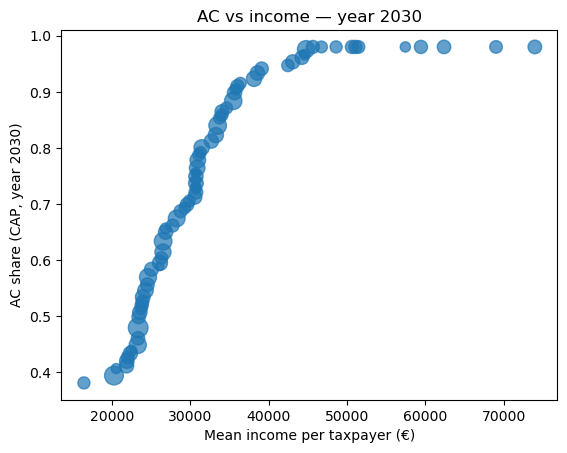

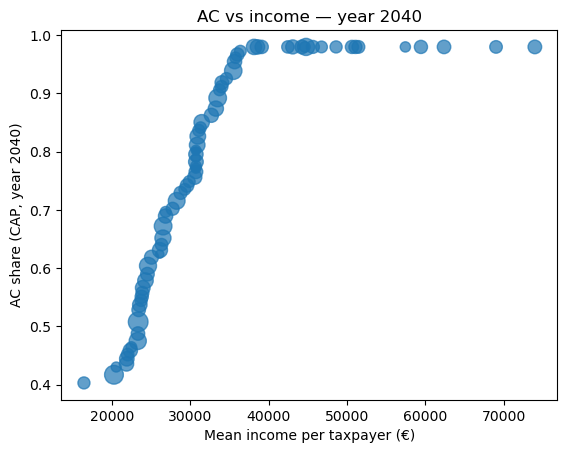

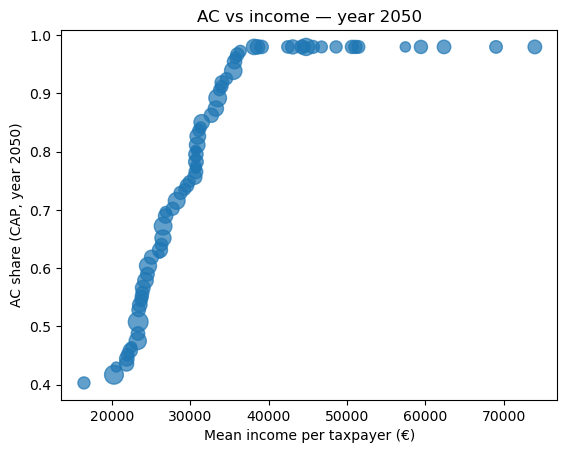

In [98]:
pd.options.display.float_format = "{:,.3f}".format

def weighted_corr(x, y, w):
    x = np.asarray(x, float); y = np.asarray(y, float); w = np.asarray(w, float)
    m_x = np.average(x, weights=w); m_y = np.average(y, weights=w)
    cov = np.average((x - m_x) * (y - m_y), weights=w)
    sx = np.sqrt(np.average((x - m_x)**2, weights=w))
    sy = np.sqrt(np.average((y - m_y)**2, weights=w))
    return cov / (sx * sy) if (sx > 0 and sy > 0) else np.nan

for y in YEARS_AC:
    print(f"\n=== QA for year {y} ===")
    cap_sub = make_cap_sub_for_year(y)

    n_show = min(8, len(cap_sub))

    print("Poorest CAPs (by clipped income rank): expect low p_inc & low AC")
    display(cap_sub.sort_values("inc_rank_base", kind="mergesort").head(n_show))

    print("\nRichest CAPs (by clipped income rank): expect high p_inc & high AC")
    display(cap_sub.sort_values("inc_rank_base", ascending=False, kind="mergesort").head(n_show))

    print("\nUnweighted Pearson corr (inc_mean vs AC):")
    display(cap_sub[["inc_mean", "ac_cap_year"]].corr().round(3))

    wc = weighted_corr(cap_sub["inc_mean"], cap_sub["ac_cap_year"], cap_sub["pop_cap"])
    mean_pop = np.average(cap_sub["ac_cap_year"], weights=cap_sub["pop_cap"])
    print(f"Weighted Pearson corr (by grid pop): {wc:.3f}")
    print(f"Pop-weighted mean AC share: {mean_pop:.3f}")

    size = 200 * np.sqrt(cap_sub["pop_cap"] / cap_sub["pop_cap"].max())
    size = np.clip(size, 10, None)

    ax = cap_sub.plot.scatter(x="inc_mean", y="ac_cap_year", s=size, alpha=0.7)
    ax.set_xlabel("Mean income per taxpayer (€)")
    ax.set_ylabel(f"AC share (CAP, year {y})")
    ax.set_title(f"AC vs income — year {y}")

**Current CAP AC Coverage on CLIMADA GRID**


===== YEAR 2030 =====
[QA] City pop-w mean on grid 2030: 0.706 (target 0.706)
[QA] City pop-w mean from CAP agg: 0.706 (target 0.706)
[QA] City pop-w mean (CITY_MASK): 0.706 (target 0.706)


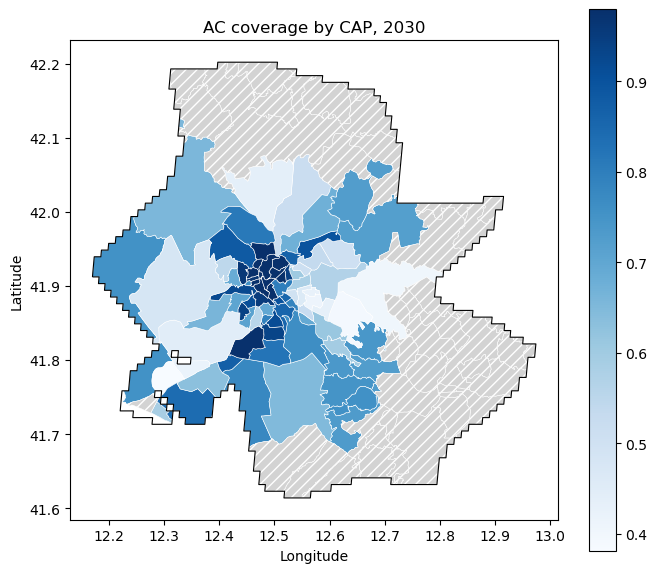


Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,41,00119,0.381,"17,621.181",38.092
1,53,00133,0.394,"103,728.387",39.407
2,52,00132,0.407,"8,590.451",40.654
3,88,00172,0.412,"35,544.091",41.151
4,48,00126,0.420,"37,363.317",41.983
5,87,00171,0.427,"20,995.874",42.657
6,86,00169,0.433,"34,966.397",43.310
7,103,00188,0.439,"11,587.981",43.858
8,67,00148,0.449,"71,779.269",44.851
9,93,00177,0.461,"27,316.796",46.050


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,112,00199,0.980,"23,655.270",98.000
1,101,00186,0.980,"25,059.878",98.000
2,109,00196,0.980,"15,981.707",98.000
3,108,00195,0.980,"17,976.470",98.000
4,107,00193,0.980,"9,290.892",98.000
5,102,00187,0.980,"20,959.327",98.000
6,99,00184,0.980,"24,700.875",98.000
7,78,00161,0.980,"21,992.931",98.000
8,105,00191,0.980,"24,897.302",98.000
9,110,00197,0.980,"28,695.673",98.000



===== YEAR 2040 =====
[QA] City pop-w mean on grid 2040: 0.740 (target 0.740)
[QA] City pop-w mean from CAP agg: 0.740 (target 0.740)
[QA] City pop-w mean (CITY_MASK): 0.740 (target 0.740)


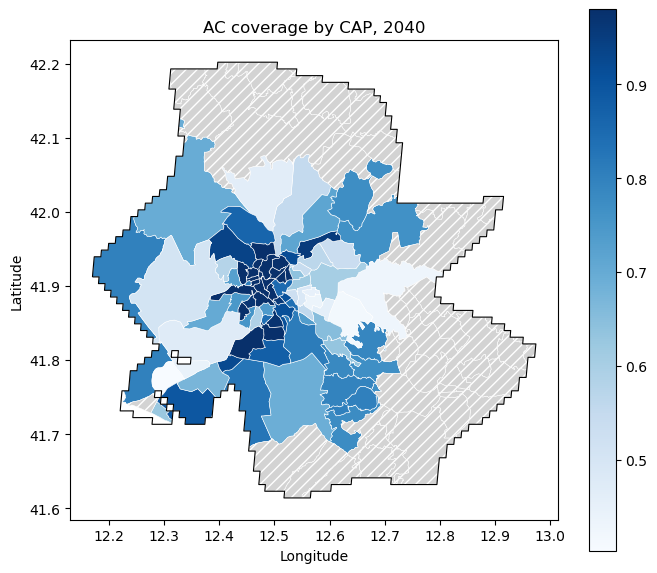


Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,41,00119,0.403,"17,621.181",40.286
1,53,00133,0.417,"103,728.387",41.689
2,52,00132,0.430,"8,590.451",43.018
3,88,00172,0.435,"35,544.091",43.549
4,48,00126,0.444,"37,363.317",44.435
5,87,00171,0.452,"20,995.874",45.154
6,86,00169,0.459,"34,966.397",45.850
7,103,00188,0.464,"11,587.981",46.435
8,67,00148,0.475,"71,779.269",47.494
9,93,00177,0.488,"27,316.796",48.773


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,112,00199,0.980,"23,655.270",98.000
1,63,00144,0.980,"72,016.976",98.000
2,101,00186,0.980,"25,059.878",98.000
3,79,00162,0.980,"19,411.480",98.000
4,69,00151,0.980,"26,114.416",98.000
5,82,00165,0.980,"45,832.143",98.000
6,102,00187,0.980,"20,959.327",98.000
7,99,00184,0.980,"24,700.875",98.000
8,78,00161,0.980,"21,992.931",98.000
9,61,00142,0.980,"36,202.428",98.000



===== YEAR 2050 =====
[QA] City pop-w mean on grid 2050: 0.740 (target 0.740)
[QA] City pop-w mean from CAP agg: 0.740 (target 0.740)
[QA] City pop-w mean (CITY_MASK): 0.740 (target 0.740)


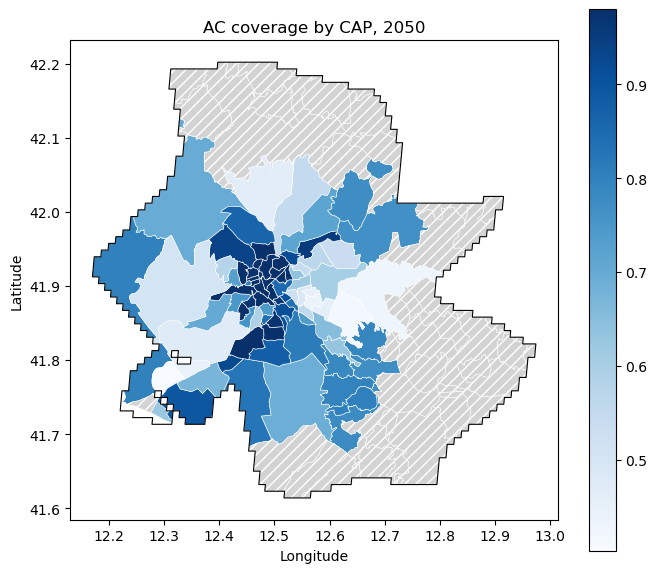


Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,41,00119,0.403,"17,621.181",40.286
1,53,00133,0.417,"103,728.387",41.689
2,52,00132,0.430,"8,590.451",43.018
3,88,00172,0.435,"35,544.091",43.549
4,48,00126,0.444,"37,363.317",44.435
5,87,00171,0.452,"20,995.874",45.154
6,86,00169,0.459,"34,966.397",45.850
7,103,00188,0.464,"11,587.981",46.435
8,67,00148,0.475,"71,779.269",47.494
9,93,00177,0.488,"27,316.796",48.773


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,112,00199,0.980,"23,655.270",98.000
1,63,00144,0.980,"72,016.976",98.000
2,101,00186,0.980,"25,059.878",98.000
3,79,00162,0.980,"19,411.480",98.000
4,69,00151,0.980,"26,114.416",98.000
5,82,00165,0.980,"45,832.143",98.000
6,102,00187,0.980,"20,959.327",98.000
7,99,00184,0.980,"24,700.875",98.000
8,78,00161,0.980,"21,992.931",98.000
9,61,00142,0.980,"36,202.428",98.000


In [99]:
import matplotlib.pyplot as plt

for YEAR_DIAG in YEARS_AC:
    print("\n===== YEAR", YEAR_DIAG, "=====")
    k_diag = year_to_index[YEAR_DIAG]

    coverage_map = coverage_base_3d[k_diag].astype("float32").copy()

    target_ac = float(ac_city_by_year[YEAR_DIAG])
    if target_ac > 1.0:
        target_ac /= 100.0
    target_ac = float(np.clip(target_ac, 0.0, 1.0))

    if np.isnan(coverage_map[CITY_MASK]).any():
        coverage_map = np.where(
            CITY_MASK & np.isnan(coverage_map),
            target_ac,
            coverage_map
        ).astype("float32")

    assert np.isfinite(coverage_map[CITY_MASK]).all(), "Non-finite coverage inside CITY_MASK."

    m_city = CITY_MASK & np.isfinite(coverage_map) & (pop_on_ref > 0)
    w = pop_on_ref[m_city]
    x = coverage_map[m_city]
    mean_pw = float(np.nansum(x * w) / np.nansum(w))

    print(f"[QA] City pop-w mean on grid {YEAR_DIAG}: {mean_pw:.3f} (target {target_ac:.3f})")

    valid = CAP_PIX
    df_capgrid = pd.DataFrame({
        "cap_id": cap_on_ref[valid].ravel().astype(int),
        "pop":    pop_on_ref[valid].ravel().astype(float),
        "cov":    coverage_map[valid].ravel().astype(float),
    })
    df_capgrid = df_capgrid[df_capgrid["cap_id"] > 0]

    def wavg(g):
        w = g["pop"].to_numpy(dtype=float)
        x = g["cov"].to_numpy(dtype=float)
        return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

    cap_pw   = df_capgrid.groupby("cap_id").apply(wavg).reset_index(name="ac_cov_pw")
    cap_pop  = (df_capgrid.groupby("cap_id", as_index=False)["pop"]
                .sum().rename(columns={"pop":"pop_cap"}))
    cap_disp = (df_capgrid.groupby("cap_id")
                .agg(ac_min=("cov","min"), ac_med=("cov","median"),
                     ac_max=("cov","max"), n_pix=("cov","size"))
                .reset_index())
    cap_cov = cap_pw.merge(cap_pop, on="cap_id", how="left").merge(cap_disp, on="cap_id", how="left")
    cap_map = cap_4326.merge(cap_cov, on="cap_id", how="left")

    cov_city_check = float(np.nansum(df_capgrid["cov"] * df_capgrid["pop"]) / np.nansum(df_capgrid["pop"]))
    cov_city_all = float(np.nansum(coverage_map[m_city] * pop_on_ref[m_city]) / np.nansum(pop_on_ref[m_city]))
    print(f"[QA] City pop-w mean from CAP agg: {cov_city_check:.3f} (target {target_ac:.3f})")
    print(f"[QA] City pop-w mean (CITY_MASK): {cov_city_all:.3f} (target {target_ac:.3f})")

    ax = fua.to_crs("EPSG:4326").boundary.plot(
        edgecolor="black", facecolor="none", linewidth=0.8, figsize=(7,6)
    )
    cap_map.to_crs("EPSG:4326").plot(
        ax=ax, column="ac_cov_pw", cmap="Blues", legend=True,
        edgecolor="white", linewidth=0.4,
        missing_kwds={"color":"lightgray","edgecolor":"white","hatch":"///","label":"No data"}
    )
    ax.set_title(f"AC coverage by CAP, {YEAR_DIAG}")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.figure.tight_layout()
    plt.show()

    tbl = (cap_map[["cap_id","cap5","ac_cov_pw","pop_cap"]]
           .dropna(subset=["ac_cov_pw"])
           .assign(ac_pct=lambda d: 100*d["ac_cov_pw"])
           .sort_values("ac_pct"))

    print("\nLowest-coverage CAPs:")
    display(tbl.head(10).reset_index(drop=True))

    print("Highest-coverage CAPs:")
    display(tbl.tail(10).sort_values("ac_pct", ascending=False).reset_index(drop=True))

In [100]:
import matplotlib.pyplot as plt

# for each of the year 2030, 2040, 2050
for y in YEARS_AC:
    print("\n" + "="*20 + f" YEAR {y} " + "="*20)
    YEAR_DIAG = y
    k_diag    = year_to_index[YEAR_DIAG]

    # coverage on grid for this year 
    coverage_map = coverage_base_3d[k_diag].astype("float32").copy()

    # target citywide mean for that year 
    target_ac = float(ac_city_by_year[YEAR_DIAG])
    if target_ac > 1.0:
        target_ac /= 100.0
    target_ac = float(np.clip(target_ac, 0.0, 1.0))

    # fill any remaining NaNs inside CITY_MASK with the city mean for that year
    if np.isnan(coverage_map[CITY_MASK]).any():
        coverage_map = np.where(
            CITY_MASK & np.isnan(coverage_map),
            target_ac,
            coverage_map
        ).astype("float32")

    # assert no NaNs where we care
    assert np.isfinite(coverage_map[CITY_MASK]).all(), \
        f"Non-finite coverage inside CITY_MASK for year {YEAR_DIAG}."

    # city pop-weighted mean on grid
    m_city = CITY_MASK & np.isfinite(coverage_map) & (pop_on_ref > 0)
    w = pop_on_ref[m_city]
    x = coverage_map[m_city]
    mean_pw = float(np.nansum(x * w) / np.nansum(w))

    print(f"[QA] City pop-w mean on grid {YEAR_DIAG}: {mean_pw:.3f} (target {target_ac:.3f})")

    # CAP aggregation + map for this year 
    valid = CAP_PIX
    df_capgrid = pd.DataFrame({
        "cap_id": cap_on_ref[valid].ravel().astype(int),
        "pop":    pop_on_ref[valid].ravel().astype(float),
        "cov":    coverage_map[valid].ravel().astype(float),
    })
    df_capgrid = df_capgrid[df_capgrid["cap_id"] > 0]

    def wavg(g):
        w = g["pop"].to_numpy(dtype=float)
        x = g["cov"].to_numpy(dtype=float)
        return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

    cap_pw   = df_capgrid.groupby("cap_id").apply(wavg).reset_index(name="ac_cov_pw")
    cap_pop  = (df_capgrid.groupby("cap_id", as_index=False)["pop"]
                .sum().rename(columns={"pop":"pop_cap"}))
    cap_disp = (df_capgrid.groupby("cap_id")
                .agg(ac_min=("cov","min"), ac_med=("cov","median"),
                     ac_max=("cov","max"), n_pix=("cov","size"))
                .reset_index())
    cap_cov = cap_pw.merge(cap_pop, on="cap_id", how="left").merge(cap_disp, on="cap_id", how="left")
    cap_map = cap_4326.merge(cap_cov, on="cap_id", how="left")

    cov_city_check = float(np.nansum(df_capgrid["cov"] * df_capgrid["pop"]) / np.nansum(df_capgrid["pop"]))
    cov_city_all   = float(np.nansum(coverage_map[m_city] * pop_on_ref[m_city]) / np.nansum(pop_on_ref[m_city]))
    print(f"[QA] City pop-w mean from CAP agg: {cov_city_check:.3f} (target {target_ac:.3f})")
    print(f"[QA] City pop-w mean (CITY_MASK): {cov_city_all:.3f} (target {target_ac:.3f})")

    # consistency checks by year 
    # pixels we actually painted from CAPs
    df_capgrid_cons = df_capgrid.copy()

    cap_pw_cons  = df_capgrid_cons.groupby("cap_id").apply(wavg).reset_index(name="ac_cov_pw")
    cap_pop_cons = (df_capgrid_cons.groupby("cap_id", as_index=False)["pop"]
                    .sum().rename(columns={"pop":"pop_cap"}))
    cap_cov_cons = cap_pw_cons.merge(cap_pop_cons, on="cap_id", how="left")

    # year-specific CAP targets
    df_target = cap_stats[["cap_id"]].copy()
    df_target["ac_cap_target"] = ac_cap_by_year[YEAR_DIAG]

    cap_join = cap_cov_cons.merge(df_target, on="cap_id", how="left")

    diff = np.abs(cap_join["ac_cov_pw"] - cap_join["ac_cap_target"])
    err_cap = float(np.nanmax(diff)) if np.any(np.isfinite(diff)) else 0.0
    print(f"[{YEAR_DIAG}] Max per-CAP diff (grid vs CAP table): {err_cap:.3e}")

    # grid-level bounds respected
    m_city2 = CITY_MASK & np.isfinite(coverage_map)
    print(f"[{YEAR_DIAG}] Min/Max coverage on grid:",
          float(np.nanmin(coverage_map[m_city2])),
          float(np.nanmax(coverage_map[m_city2])))

    w2 = np.where(m_city2, pop_on_ref, 0.0)
    at_floor = np.isclose(coverage_map, ac_min, atol=1e-6)
    at_cap   = np.isclose(coverage_map, ac_max, atol=1e-6)
    print(f"[{YEAR_DIAG}] Pop share at floor:", float(np.nansum(w2 * at_floor) / np.nansum(w2)))
    print(f"[{YEAR_DIAG}] Pop share at cap:  ", float(np.nansum(w2 * at_cap)   / np.nansum(w2)))

    print(f"[{YEAR_DIAG}] Grid pop-weighted mean:",
          float(np.nansum(coverage_map[m_city2] * pop_on_ref[m_city2]) /
                np.nansum(pop_on_ref[m_city2])))

    # tables: lowest / highest coverage CAPs for this year
    tbl = (cap_map[["cap_id","cap5","ac_cov_pw","pop_cap"]]
           .dropna(subset=["ac_cov_pw"])
           .assign(ac_pct=lambda d: 100*d["ac_cov_pw"])
           .sort_values("ac_pct"))

    print("\nLowest-coverage CAPs:")
    display(tbl.head(10).reset_index(drop=True))

    print("Highest-coverage CAPs:")
    display(tbl.tail(10).sort_values("ac_pct", ascending=False).reset_index(drop=True))


==================== YEAR 2030 ====================
[QA] City pop-w mean on grid 2030: 0.706 (target 0.706)
[QA] City pop-w mean from CAP agg: 0.706 (target 0.706)
[QA] City pop-w mean (CITY_MASK): 0.706 (target 0.706)
[2030] Max per-CAP diff (grid vs CAP table): 2.864e-08
[2030] Min/Max coverage on grid: 0.3809192180633545 0.9800000190734863
[2030] Pop share at floor: 0.0
[2030] Pop share at cap:   0.09456785023212433
[2030] Grid pop-weighted mean: 0.7057378888130188

Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,41,00119,0.381,"17,621.181",38.092
1,53,00133,0.394,"103,728.387",39.407
2,52,00132,0.407,"8,590.451",40.654
3,88,00172,0.412,"35,544.091",41.151
4,48,00126,0.420,"37,363.317",41.983
5,87,00171,0.427,"20,995.874",42.657
6,86,00169,0.433,"34,966.397",43.310
7,103,00188,0.439,"11,587.981",43.858
8,67,00148,0.449,"71,779.269",44.851
9,93,00177,0.461,"27,316.796",46.050


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,112,00199,0.980,"23,655.270",98.000
1,101,00186,0.980,"25,059.878",98.000
2,109,00196,0.980,"15,981.707",98.000
3,108,00195,0.980,"17,976.470",98.000
4,107,00193,0.980,"9,290.892",98.000
5,102,00187,0.980,"20,959.327",98.000
6,99,00184,0.980,"24,700.875",98.000
7,78,00161,0.980,"21,992.931",98.000
8,105,00191,0.980,"24,897.302",98.000
9,110,00197,0.980,"28,695.673",98.000



==================== YEAR 2040 ====================
[QA] City pop-w mean on grid 2040: 0.740 (target 0.740)
[QA] City pop-w mean from CAP agg: 0.740 (target 0.740)
[QA] City pop-w mean (CITY_MASK): 0.740 (target 0.740)
[2040] Max per-CAP diff (grid vs CAP table): 2.917e-08
[2040] Min/Max coverage on grid: 0.40286433696746826 0.9800000190734863
[2040] Pop share at floor: 0.0
[2040] Pop share at cap:   0.20198185741901398
[2040] Grid pop-weighted mean: 0.7400425672531128

Lowest-coverage CAPs:


...

,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,112,00199,0.980,"23,655.270",98.000
1,63,00144,0.980,"72,016.976",98.000
2,101,00186,0.980,"25,059.878",98.000
3,79,00162,0.980,"19,411.480",98.000
4,69,00151,0.980,"26,114.416",98.000
5,82,00165,0.980,"45,832.143",98.000
6,102,00187,0.980,"20,959.327",98.000
7,99,00184,0.980,"24,700.875",98.000
8,78,00161,0.980,"21,992.931",98.000
9,61,00142,0.980,"36,202.428",98.000



==================== YEAR 2050 ====================
[QA] City pop-w mean on grid 2050: 0.740 (target 0.740)
[QA] City pop-w mean from CAP agg: 0.740 (target 0.740)
[QA] City pop-w mean (CITY_MASK): 0.740 (target 0.740)
[2050] Max per-CAP diff (grid vs CAP table): 2.917e-08
[2050] Min/Max coverage on grid: 0.40286433696746826 0.9800000190734863
[2050] Pop share at floor: 0.0
[2050] Pop share at cap:   0.20198185741901398
[2050] Grid pop-weighted mean: 0.7400425672531128

Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,41,00119,0.403,"17,621.181",40.286
1,53,00133,0.417,"103,728.387",41.689
2,52,00132,0.430,"8,590.451",43.018
3,88,00172,0.435,"35,544.091",43.549
4,48,00126,0.444,"37,363.317",44.435
5,87,00171,0.452,"20,995.874",45.154
6,86,00169,0.459,"34,966.397",45.850
7,103,00188,0.464,"11,587.981",46.435
8,67,00148,0.475,"71,779.269",47.494
9,93,00177,0.488,"27,316.796",48.773


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,112,00199,0.980,"23,655.270",98.000
1,63,00144,0.980,"72,016.976",98.000
2,101,00186,0.980,"25,059.878",98.000
3,79,00162,0.980,"19,411.480",98.000
4,69,00151,0.980,"26,114.416",98.000
5,82,00165,0.980,"45,832.143",98.000
6,102,00187,0.980,"20,959.327",98.000
7,99,00184,0.980,"24,700.875",98.000
8,78,00161,0.980,"21,992.931",98.000
9,61,00142,0.980,"36,202.428",98.000


**Little note/question here: quite a lot at the CAP, but I tried to decrease the s of the logistic function and to modify the min/max, doesn't do much... I think by construction a lot are at the CAP. Problem?**

In [101]:
# building table: one row per CAP with income rank + grid pop
# we restrict to CAPs that actually have modeled population (>0) on the CLIMADA grid
cap_income_id = (
    cap_stats.loc[cap_stats["pop_cap"] > 0, ["cap_id","cap5","p_inc","pop_cap"]]
             .rename(columns={"pop_cap":"pop_cap_grid", "p_inc":"rank_key"})
)

sel = (cap_income_id.loc[cap_income_id["pop_cap_grid"] > 0,
                         ["cap_id","cap5","rank_key","pop_cap_grid"]]
       .sort_values("rank_key")   # still ascending: poorer first
       .reset_index(drop=True))

All the targets changed well since we went from netCDF to CSV ! perfect

## AC Policy

some notes on following code:
- we rank CAPs by income but we cumulate the WorldPop pop, not the taxpayers anymore
- New policy!! 

**Catch-up policy** : 70% AC coverage for 50% poorest by CAP income rank with uniform efficacy : 0.3 and age-varying efficacy (an efficacy per age bucket): this needs **calibration**

In [102]:
# AC policy 

import numpy as np, pandas as pd

# reading para from YAML if present 
ac_cfg   = cfg.get("ac", {})
pol_cfg  = cfg.get("ac_policy", {})  
X_SHARE  = float(pol_cfg.get("target_share_by_pop", 0.50))   # 50% poorest by grid pop
TARGET   = float(pol_cfg.get("target_level",        0.70))   # lift to 70%
TOL      = float(pol_cfg.get("tol",                 1e-6))  

# AC bounds 
AC_LO = float(ac_cfg.get("ac_min", 0.05))
AC_HI = float(ac_cfg.get("ac_max", 0.98))

# helpers 
def popw_mean(arr, mask=None):
    m = np.isfinite(arr) & np.isfinite(pop_on_ref) & (pop_on_ref > 0)
    if mask is not None:
        m &= mask
    if not np.any(m):
        return np.nan
    w = pop_on_ref[m].astype(float)
    x = arr[m].astype(float)
    den = np.sum(w)
    return float(np.sum(x * w) / den) if den > 0 else np.nan

def cap_popw_mean_from(arr, valid_mask, name):
    m = valid_mask & np.isfinite(arr) & np.isfinite(pop_on_ref) & (pop_on_ref > 0)
    if not np.any(m):
        return pd.DataFrame(columns=["cap_id", name])
    df = pd.DataFrame({
        "cap_id": cap_on_ref[m].ravel().astype(int),
        name:     arr[m].ravel().astype(float),
        "w":      pop_on_ref[m].ravel().astype(float),
    })
    out = (df.groupby("cap_id")
             .apply(lambda g: float(np.sum(g[name]*g["w"]) / np.sum(g["w"]))
                              if g["w"].sum() > 0 else np.nan)
             .reset_index(name=name))
    return out

# selector input anchored to the grid universe 
need_cols = {"cap_id","cap5","inc_rank_base","pop_cap"}
missing = need_cols - set(cap_stats.columns)
if missing:
    raise KeyError(f"cap_stats missing columns: {sorted(missing)}")

# ensuring p_inc exists (same percentile rule)
if "p_inc" not in cap_stats.columns:
    cap_stats["p_inc"] = weighted_percentile_rank(
        cap_stats["inc_rank_base"].to_numpy(),
        cap_stats["pop_cap"].to_numpy()
    ).clip(1e-3, 1-1e-3)

cap_income_id = (
    cap_stats.loc[cap_stats["pop_cap"] > 0,
                  ["cap_id","cap5","inc_rank_base","p_inc","pop_cap"]]
             .rename(columns={"pop_cap": "pop_cap_grid"})
             .assign(cap_id=lambda d: d["cap_id"].astype(int),
                     pop_cap_grid=lambda d: d["pop_cap_grid"].astype(float))
             .reset_index(drop=True)
)

# sorting poorer to richer
sel = (cap_income_id.loc[cap_income_id["pop_cap_grid"] > 0,
                         ["cap_id","cap5","inc_rank_base","p_inc","pop_cap_grid"]]
       .sort_values(["inc_rank_base","cap_id"], kind="mergesort")
       .reset_index(drop=True))

# cumulative pop population share in CAP universe
if sel.empty:
    raise ValueError("No CAPs with positive grid population in CAP_PIX.")

total_pop = float(sel["pop_cap_grid"].sum())
if total_pop <= 0:
    raise ValueError("Zero total grid population in CAP_PIX; check pop_on_ref / CAP_PIX.")

sel["cum_pop"]   = sel["pop_cap_grid"].cumsum()
sel["cum_share"] = sel["cum_pop"] / total_pop

# choosing cutoff closest to X_SHARE 
cum = sel["cum_share"].to_numpy()
idx_hi   = int(np.searchsorted(cum, X_SHARE, side="left"))
idx_hi   = min(max(idx_hi, 0), len(sel)-1)
share_hi = float(cum[idx_hi])
share_lo = float(cum[idx_hi-1]) if idx_hi > 0 else 0.0
use_hi   = (abs(share_hi - X_SHARE) <= abs(share_lo - X_SHARE))
cut_idx  = idx_hi if use_hi else (idx_hi - 1)

target_ids = np.array(
    sorted(set(sel.loc[:cut_idx, "cap_id"].astype(int).to_numpy())),
    dtype=int
)

# diagnostics 
num = float(np.nansum(pop_on_ref[CAP_PIX & np.isin(cap_on_ref, target_ids)]))
den = float(np.nansum(pop_on_ref[CAP_PIX]))
share = num / den if den > 0 else np.nan
print(f"Selection share (grid, cap_id-based): {share:.2%} "
      f"(X_SHARE={100*X_SHARE:.0f}%, lo={100*share_lo:.2f}%, hi={100*share_hi:.2f}%, "
      f"picked={'hi' if use_hi else 'lo'})")

Selection share (grid, cap_id-based): 49.83% (X_SHARE=50%, lo=49.83%, hi=51.12%, picked=lo)


In [103]:
# multi-year AC policy: building policy coverage maps for each AC year 

year_to_index = {y: idx for idx, y in enumerate(YEARS_AC)}
n_years = len(YEARS_AC)

max_cap_id = int(cap_stats["cap_id"].max())
cap_ids    = cap_stats["cap_id"].astype(int).to_numpy()

coverage_policy_3d = np.full_like(coverage_base_3d, np.nan, dtype="float32")

for y in YEARS_AC:
    k = year_to_index[y]
    print(f"\n=== AC policy for year {y} ===")

    # baseline CAP-level coverage for this year (vector aligned with cap_stats)
    base_cap_vec = ac_cap_by_year[y].astype(float)  # length = len(cap_stats)

    # per-CAP policy table for this year
    cap_tbl = pd.DataFrame({
        "cap_id": cap_ids,
        "ac_cap_baseline": base_cap_vec,
    })
    cap_tbl["is_target"] = np.isin(cap_tbl["cap_id"].to_numpy(), target_ids)

    cap_tbl["ac_cap_policy"] = np.where(
        cap_tbl["is_target"],
        np.maximum(cap_tbl["ac_cap_baseline"], TARGET),
        cap_tbl["ac_cap_baseline"]
    ).clip(AC_LO, AC_HI)

    # lookup arrays cap_id -> coverage
    ac_lut_base   = np.full(max_cap_id + 1, np.nan, dtype="float32")
    ac_lut_policy = np.full_like(ac_lut_base, np.nan)

    idx = cap_tbl["cap_id"].astype(int).to_numpy()
    ac_lut_base[idx]   = cap_tbl["ac_cap_baseline"].astype("float32").to_numpy()
    ac_lut_policy[idx] = cap_tbl["ac_cap_policy"].astype("float32").to_numpy()

    # fill missing baseline with city mean for that year
    city_mean_y = float(ac_city_by_year[y])
    if city_mean_y > 1.0:
        city_mean_y /= 100.0
    city_mean_y = float(np.clip(city_mean_y, 0.0, 1.0))

    nan_pol = np.isnan(ac_lut_policy)
    ac_lut_policy[nan_pol] = ac_lut_base[nan_pol]
    nan_base = np.isnan(ac_lut_base)
    ac_lut_base[nan_base] = city_mean_y

    # baseline map for this year already exists
    coverage_base_y   = coverage_base_3d[k].astype("float32").copy()

    # policy map for this year: paint CAP values onto grid
    coverage_policy_y = np.full(ref_data.shape, np.nan, dtype="float32")
    inside_cap_haz    = CAP_PIX  # CAP label and inside city
    if np.any(inside_cap_haz):
        coverage_policy_y[inside_cap_haz] = ac_lut_policy[cap_on_ref[inside_cap_haz]]

    # if any city pixels still NaN in policy map, keep baseline
    mask_nan = CITY_MASK & np.isnan(coverage_policy_y)
    coverage_policy_y[mask_nan] = coverage_base_y[mask_nan]

    # valid analysis mask for this year
    CAP_MASK_y = CAP_PIX & np.isfinite(coverage_base_y) & np.isfinite(coverage_policy_y)

    # citywide pop-weighted means (diagnostics)
    mean_base = popw_mean(coverage_base_y,   CAP_MASK_y)
    mean_pol  = popw_mean(coverage_policy_y, CAP_MASK_y)
    print(f"City AC baseline (pop-w, CAP_PIX): {mean_base:.3f}")
    print(f"City AC policy   (pop-w, CAP_PIX): {mean_pol:.3f}")
    print(f"Δ mean (pp): {100*(mean_pol - mean_base):.2f}")

    # simple LUT violations check (per CAP, for this year)
    base = cap_tbl["ac_cap_baseline"].to_numpy()
    pol  = cap_tbl["ac_cap_policy"].to_numpy()
    targ_mask_tbl = cap_tbl["is_target"].to_numpy()

    v1 = (targ_mask_tbl & (base + TOL < TARGET) & (pol + TOL < TARGET))
    v2 = (targ_mask_tbl & (base >= TARGET - TOL) & (pol + TOL < base - 1e-12))
    print(f"[{y}] LUT violations (should be 0, 0):", int(v1.sum()), int(v2.sum()))

    # save in 3D array
    coverage_policy_3d[k] = coverage_policy_y

# in case we needed (from before) 
coverage_base   = coverage_base_3d[YEARS_AC.index(2050)]
coverage_policy = coverage_policy_3d[YEARS_AC.index(2050)]


=== AC policy for year 2030 ===
City AC baseline (pop-w, CAP_PIX): 0.706
City AC policy   (pop-w, CAP_PIX): 0.788
Δ mean (pp): 8.20
[2030] LUT violations (should be 0, 0): 0 0

=== AC policy for year 2040 ===
City AC baseline (pop-w, CAP_PIX): 0.740
City AC policy   (pop-w, CAP_PIX): 0.808
Δ mean (pp): 6.76
[2040] LUT violations (should be 0, 0): 0 0

=== AC policy for year 2050 ===
City AC baseline (pop-w, CAP_PIX): 0.740
City AC policy   (pop-w, CAP_PIX): 0.808
Δ mean (pp): 6.76
[2050] LUT violations (should be 0, 0): 0 0


In [104]:
# config-driven names
KEYS = cfg.get("keys", {})  # optional in YAML
CAP_CODE   = KEYS.get("cap_code", "cap5")
CAP_IDCOL  = KEYS.get("cap_id",  "cap_id")
MUNI_ID    = KEYS.get("muni_id", "muni_id")
MUNI_NAME  = KEYS.get("muni_name", "muni_name")

# display
_has_display = "display" in globals()

# CRS helper for plotting 
def _to_wgs84(gdf):
    if gdf is None or gdf.empty:
        return gdf
    crs = getattr(gdf, "crs", None)
    if crs is None:
        return gdf  
    try:
        return gdf.to_crs("EPSG:4326")
    except Exception:
        return gdf  

# diagnostics: p_inc for the targeted set
sel["is_target"] = False
sel.loc[:cut_idx, "is_target"] = True

target_view = (sel.loc[sel["is_target"],
                       [CAP_IDCOL, CAP_CODE, "inc_rank_base", "p_inc", "pop_cap_grid", "cum_share"]]
                 .assign(p_inc_pct=lambda d: (100*d["p_inc"]).round(1),
                         pop_k=lambda d: (d["pop_cap_grid"]/1000).round(1))
              )

print("Targeted CAPs (poorest first) – showing first/last 10 with p_inc:")
tv = pd.concat([target_view.head(10), target_view.tail(10)]).reset_index(drop=True)
if _has_display:
    display(tv)
else:
    print(tv)

p_boundary = float(sel.loc[cut_idx, "p_inc"])
share_boundary = float(sel.loc[cut_idx, "cum_share"])
print(f"Boundary p_inc ≈ {p_boundary:.3f} (~{p_boundary*100:.1f}th pct by people); "
      f"cum. share at boundary = {share_boundary:.2%}")

# what if we used p_inc <= boundary as the selection rule?
ids_by_pinc = (cap_income_id.loc[
                    (cap_income_id["p_inc"] <= p_boundary) &
                    (cap_income_id["pop_cap_grid"] > 0),
                    CAP_IDCOL]
               .astype(int).unique())
num2 = float(np.nansum(pop_on_ref[CAP_PIX & np.isin(cap_on_ref, ids_by_pinc)]))
den  = float(np.nansum(pop_on_ref[CAP_PIX]))
print(f"Selection share if using p_inc<=boundary: {num2/den:.2%} (vs grid-anchored {share:.2%})")

Targeted CAPs (poorest first) – showing first/last 10 with p_inc:
    cap_id   cap5  inc_rank_base  p_inc  pop_cap_grid  cum_share  p_inc_pct  \
0       41  00119     19,472.391  0.003    17,621.181      0.007      0.300   
1       53  00133     20,239.128  0.027   103,728.387      0.048      2.700   
2       52  00132     20,526.122  0.049     8,590.451      0.051      4.900   
3       88  00172     21,838.697  0.058    35,544.091      0.065      5.800   
4       48  00126     21,879.120  0.072    37,363.317      0.080      7.200   
5       87  00171     21,986.438  0.084    20,995.874      0.088      8.400   
6       86  00169     22,324.881  0.095    34,966.397      0.102      9.500   
7      103  00188     22,460.978  0.104    11,587.981      0.106     10.400   
8       67  00148     23,274.837  0.120    71,779.269      0.134     12.000   
9       93  00177     23,305.890  0.140    27,316.796      0.145     14.000   
10      89  00173     26,492.326  0.369    56,324.068      0.380 

In [105]:
# CAP-level coverage table and maps for a chosen diagnostic year

YEAR_DIAG = 2050  # we can change to 2030/2040/2050 as needed
# just didn't want to print all the outputs together 
k_diag    = year_to_index[YEAR_DIAG]

coverage_base_diag   = coverage_base_3d[k_diag].astype("float32")
coverage_policy_diag = coverage_policy_3d[k_diag].astype("float32")

# mask where both baseline and policy are defined for this year
CAP_MASK_diag = CAP_PIX & np.isfinite(coverage_base_diag) & np.isfinite(coverage_policy_diag)

# CAP-level coverage table (baseline, policy, change)
valid_b = CAP_MASK_diag & np.isfinite(coverage_base_diag)
valid_p = CAP_MASK_diag & np.isfinite(coverage_policy_diag)

cap_base = cap_popw_mean_from(coverage_base_diag,   valid_b, "ac_base")
cap_pol  = cap_popw_mean_from(coverage_policy_diag, valid_p, "ac_policy")

cap_cov  = (cap_base.merge(cap_pol, on=CAP_IDCOL, how="outer")
                    .assign(delta=lambda d: d["ac_policy"] - d["ac_base"]))

cap_pop = (pd.DataFrame({
                CAP_IDCOL: cap_on_ref[CAP_MASK_diag].ravel().astype(int),
                "pop":     pop_on_ref[CAP_MASK_diag].ravel().astype(float)
           })
           .groupby(CAP_IDCOL, as_index=False)["pop"].sum()
           .rename(columns={"pop":"pop_cap"}))

cap_cov = (cap_cov.merge(cap_pop, on=CAP_IDCOL, how="left")
                 .merge(cap_4326[[CAP_IDCOL, CAP_CODE]], on=CAP_IDCOL, how="left"))

# building map GeoDataFrame for this year
cap_map = cap_4326.merge(
    cap_cov[[CAP_IDCOL,"ac_base","ac_policy","delta"]],
    on=CAP_IDCOL, how="left"
)

# ranges for baseline/policy
_min_base, _min_pol = cap_cov["ac_base"].min(),   cap_cov["ac_policy"].min()
_max_base, _max_pol = cap_cov["ac_base"].max(),   cap_cov["ac_policy"].max()
vmin = float(np.nanmin([_min_base, _min_pol])) if np.isfinite([_min_base, _min_pol]).any() else 0.0
vmax = float(np.nanmax([_max_base, _max_pol])) if np.isfinite([_max_base, _max_pol]).any() else 1.0

dv   = float(np.nanpercentile(
                np.abs(cap_map["delta"].to_numpy(dtype=float)), 99
             )) if "delta" in cap_map else 0.0
if not np.isfinite(dv) or dv == 0.0:
    dv = 0.0  # keeps plotting but avoids NaN ranges

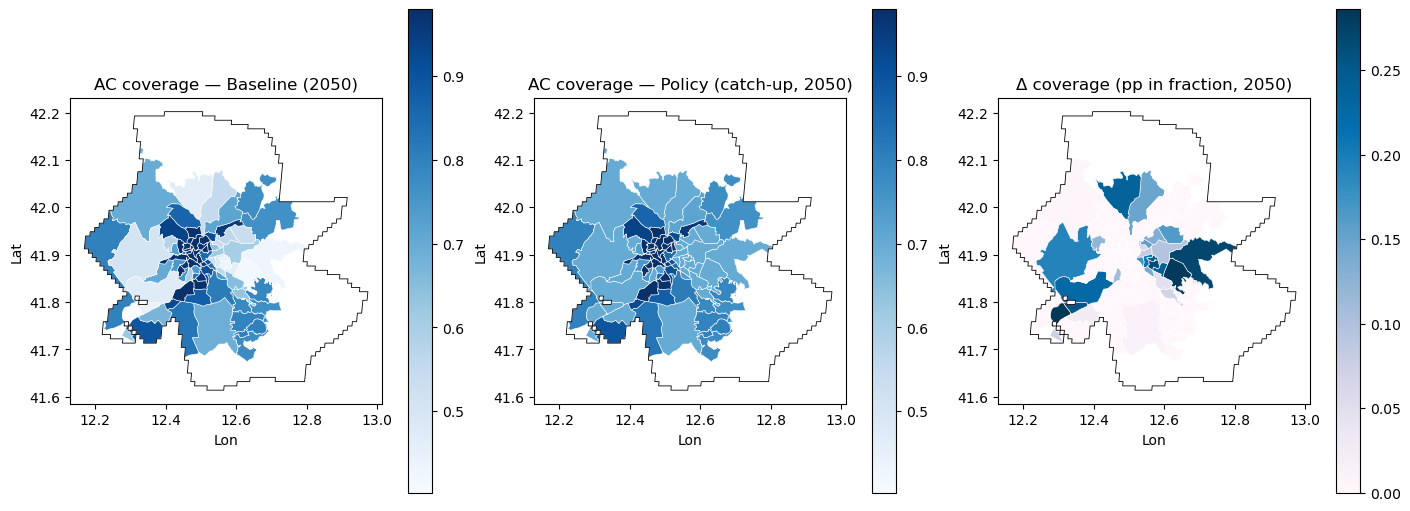

In [106]:
# plot maps
fig, ax = plt.subplots(1,3, figsize=(14,5), constrained_layout=True)

_fua_wgs    = _to_wgs84(fua) if "fua" in globals() else None
_capmap_wgs = _to_wgs84(cap_map)

if _fua_wgs is not None:
    _fua_wgs.boundary.plot(ax=ax[0], color="k", lw=0.6)
_capmap_wgs.plot(
    ax=ax[0], column="ac_base", cmap="Blues",
    vmin=vmin, vmax=vmax, edgecolor="white", lw=0.4, legend=True
)
ax[0].set_title(f"AC coverage — Baseline ({YEAR_DIAG})")
ax[0].set_xlabel("Lon"); ax[0].set_ylabel("Lat")

if _fua_wgs is not None:
    _fua_wgs.boundary.plot(ax=ax[1], color="k", lw=0.6)
_capmap_wgs.plot(
    ax=ax[1], column="ac_policy", cmap="Blues",
    vmin=vmin, vmax=vmax, edgecolor="white", lw=0.4, legend=True
)
ax[1].set_title(f"AC coverage — Policy (catch-up, {YEAR_DIAG})")
ax[1].set_xlabel("Lon"); ax[1].set_ylabel("Lat")

if _fua_wgs is not None:
    _fua_wgs.boundary.plot(ax=ax[2], color="k", lw=0.6)
_capmap_wgs.plot(
    ax=ax[2], column="delta", cmap="PuBu",
    vmin=0.0, vmax=dv if dv > 0 else None,
    edgecolor="white", lw=0.4, legend=True
)
ax[2].set_title(f"Δ coverage (pp in fraction, {YEAR_DIAG})")
ax[2].set_xlabel("Lon"); ax[2].set_ylabel("Lat")
plt.show()

In [107]:
# tables: top/bottom changes by CAP for this YEAR_DIAG
tbl = (cap_cov.dropna(subset=["delta"])
              .assign(ac_base_pct=lambda d: 100*d["ac_base"],
                      ac_policy_pct=lambda d: 100*d["ac_policy"],
                      delta_pp=lambda d: 100*d["delta"])
              .sort_values(["delta_pp", CAP_CODE], ascending=[False, True]))

print(f"\nTop Δcoverage CAPs (year {YEAR_DIAG}):")
top_tbl = tbl[[CAP_CODE,"ac_base_pct","ac_policy_pct","delta_pp","pop_cap"]] \
              .head(10).reset_index(drop=True)
if _has_display:
    display(top_tbl)
else:
    print(top_tbl)

print(f"\nBottom (or zero) Δcoverage CAPs (year {YEAR_DIAG}):")
bot_tbl = (tbl[[CAP_CODE,"ac_base_pct","ac_policy_pct","delta_pp","pop_cap"]]
           .tail(10).sort_values("delta_pp").reset_index(drop=True))
if _has_display:
    display(bot_tbl)
else:
    print(bot_tbl)


Top Δcoverage CAPs (year 2050):
    cap5  ac_base_pct  ac_policy_pct  delta_pp     pop_cap
0  00119       40.286         70.000    29.714  17,621.181
1  00133       41.689         70.000    28.311 103,728.387
2  00132       43.018         70.000    26.982   8,590.451
3  00172       43.549         70.000    26.451  35,544.091
4  00126       44.435         70.000    25.565  37,363.317
5  00171       45.154         70.000    24.846  20,995.874
6  00169       45.850         70.000    24.150  34,966.397
7  00188       46.435         70.000    23.565  11,587.981
8  00148       47.494         70.000    22.506  71,779.269
9  00177       48.773         70.000    21.227  27,316.796

Bottom (or zero) Δcoverage CAPs (year 2050):
    cap5  ac_base_pct  ac_policy_pct  delta_pp    pop_cap
0  00187       98.000         98.000     0.000 20,959.327
1  00189       86.256         86.256     0.000 33,497.789
2  00191       98.000         98.000     0.000 24,897.302
3  00192       98.000         98.000    

In [108]:
# some checks 
# sets at each stage
caps_csv   = set(inc_agg[CAP_CODE].astype(str))
caps_shp   = set(cap_4326[CAP_CODE].astype(str)) # after FUA clip
caps_rast  = set(cap_ref[CAP_CODE].astype(str))  # after reprojection (same as caps_shp)
ids_on_grid = set(np.unique(cap_on_ref[cap_on_ref > 0]).astype(int))
caps_labeled = set(cap_ref.loc[cap_ref[CAP_IDCOL].isin(ids_on_grid), CAP_CODE].astype(str))

# CAPs with any pixel under CITY_MASK 
ids_cap_pix  = set(np.unique(cap_on_ref[CAP_PIX]).astype(int))
caps_cap_pix = set(cap_ref.loc[cap_ref[CAP_IDCOL].isin(ids_cap_pix), CAP_CODE].astype(str))

# CAPs with >0 modeled pop in CAP_PIX
df_capgrid = pd.DataFrame({
    CAP_IDCOL: cap_on_ref[CAP_PIX].ravel().astype(int),
    "pop":     pop_on_ref[CAP_PIX].ravel().astype(float),
})
df_capgrid = df_capgrid[df_capgrid[CAP_IDCOL] > 0]
pop_by_cap = (df_capgrid.groupby(CAP_IDCOL)["pop"].sum()
              .rename("pop_cap").reset_index())
caps_poppos = set(
    cap_ref.merge(pop_by_cap, on=CAP_IDCOL, how="left")
           .query("pop_cap > 0")[CAP_CODE].astype(str)
)

# buckets 
missing_in_shapes_or_outside_fua = sorted(caps_csv - caps_shp)
in_shapes_but_no_labeled_pixels  = sorted(caps_shp - caps_labeled)
labeled_but_not_in_CITY_MASK     = sorted(caps_labeled - caps_cap_pix)
in_CAP_PIX_but_zero_population   = sorted(caps_cap_pix - caps_poppos)

print("CSV CAPs:", len(caps_csv))
print("After FUA clip (polygons):", len(caps_shp))
print("Labeled on grid (any pixels):", len(caps_labeled))
print("In CAP_PIX (city mask & labeled):", len(caps_cap_pix))
print(">0 population in CAP_PIX:", len(caps_poppos))
print()
print("Missing (CSV but not in shapes/FUA):", len(missing_in_shapes_or_outside_fua), missing_in_shapes_or_outside_fua[:10])
print("No labeled pixels (resolution / all_touched=False):", len(in_shapes_but_no_labeled_pixels), in_shapes_but_no_labeled_pixels[:10])
print("Only outside CITY_MASK/hazard or pop==0 area:", len(labeled_but_not_in_CITY_MASK), labeled_but_not_in_CITY_MASK[:10])
print("Zero modeled pop in CAP_PIX:", len(in_CAP_PIX_but_zero_population), in_CAP_PIX_but_zero_population[:10])

CSV CAPs: 72
After FUA clip (polygons): 118
Labeled on grid (any pixels): 81
In CAP_PIX (city mask & labeled): 81
>0 population in CAP_PIX: 81

Missing (CSV but not in shapes/FUA): 0 []
No labeled pixels (resolution / all_touched=False): 37 ['00010', '00015', '00018', '00019', '00020', '00024', '00029', '00030', '00031', '00033']
Only outside CITY_MASK/hazard or pop==0 area: 0 []
Zero modeled pop in CAP_PIX: 0 []


Super important to understand why:
- In my income CSV there are 72 rows of 72 CAP with incomes data
- But then shapefile + FUA clip contains all CAP zones that intersect the FUA (metro area), not just the Comune di Roma → 118 CAPs. Many of those extra CAPs are the suburban/postal zones that start with 000xx (typical around Rome).
- After rasterization, 36 of those polygons don’t catch a grid cell at the resolution (all_touched=False) → “No labeled pixels”. One more has pixels but none in CITY_MASK (outside hazard or pop_on_ref==0)

**Municipi**

In [109]:
# City-agnostic config
REGION_GDF        = globals().get("regions", muni)   # GeoDataFrame of regions+outside
REGION_ID_FIELD   = "muni_id"                        # integer id per region
REGION_NAME_FIELD = "muni_name"                      # readable name
OUTSIDE_LABEL     = "Fuori Municipi (FUA)"           # label when id==0 
PLOT_LABEL        = "Municipi"                       # for plot titles


===== Municipi stats for year 2030 =====
[QA 2030] City (grid) base=0.706 vs sum-over-Municipi=0.706
[QA 2030] City (grid) pol =0.788 vs sum-over-Municipi=0.788

Top/bottom Municipi by Δ (policy - baseline), pp
    muni_id  ac_base_muni  ac_policy_muni    pop_muni  delta  delta_pp  \
6         6         0.407           0.700 129,944.773  0.293    29.261   
5         5         0.491           0.701 175,712.889  0.210    21.039   
11       11         0.535           0.704 119,803.339  0.169    16.909   
4         4         0.565           0.710 170,679.730  0.145    14.497   
13       13         0.642           0.767 130,701.854  0.125    12.516   
10       10         0.652           0.751 220,800.463  0.099     9.926   
14       14         0.709           0.793 158,462.193  0.084     8.443   
7         7         0.681           0.748 248,261.720  0.068     6.789   
12       12         0.750           0.806 131,663.471  0.056     5.562   
3         3         0.727           0.769 148,39

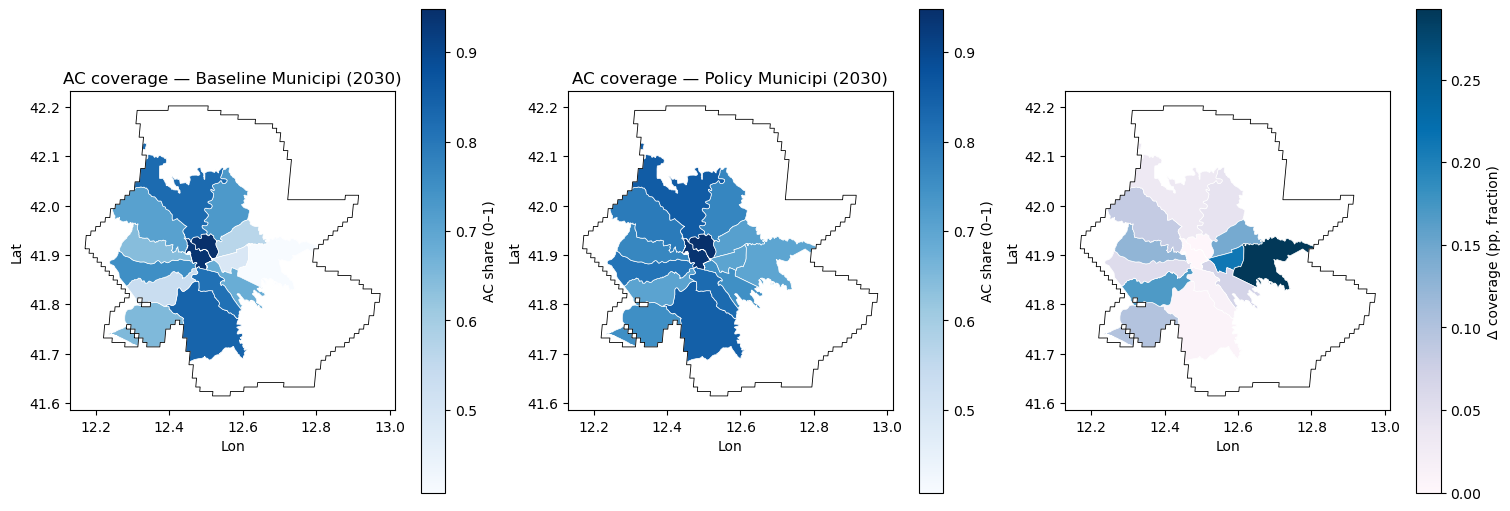


===== Municipi stats for year 2040 =====
[QA 2040] City (grid) base=0.740 vs sum-over-Municipi=0.740
[QA 2040] City (grid) pol =0.808 vs sum-over-Municipi=0.808

Top/bottom Municipi by Δ (policy - baseline), pp
    muni_id  ac_base_muni  ac_policy_muni    pop_muni  delta  delta_pp  \
6         6         0.431           0.700 129,944.773  0.269    26.892   
5         5         0.520           0.702 175,712.889  0.182    18.189   
11       11         0.567           0.715 119,803.339  0.148    14.755   
4         4         0.599           0.713 170,679.730  0.114    11.365   
13       13         0.680           0.788 130,701.854  0.107    10.711   
10       10         0.692           0.770 220,800.463  0.079     7.854   
14       14         0.747           0.814 158,462.193  0.068     6.756   
7         7         0.722           0.772 248,261.720  0.049     4.933   
12       12         0.791           0.834 131,663.471  0.043     4.324   
15       15         0.860           0.887  99,25

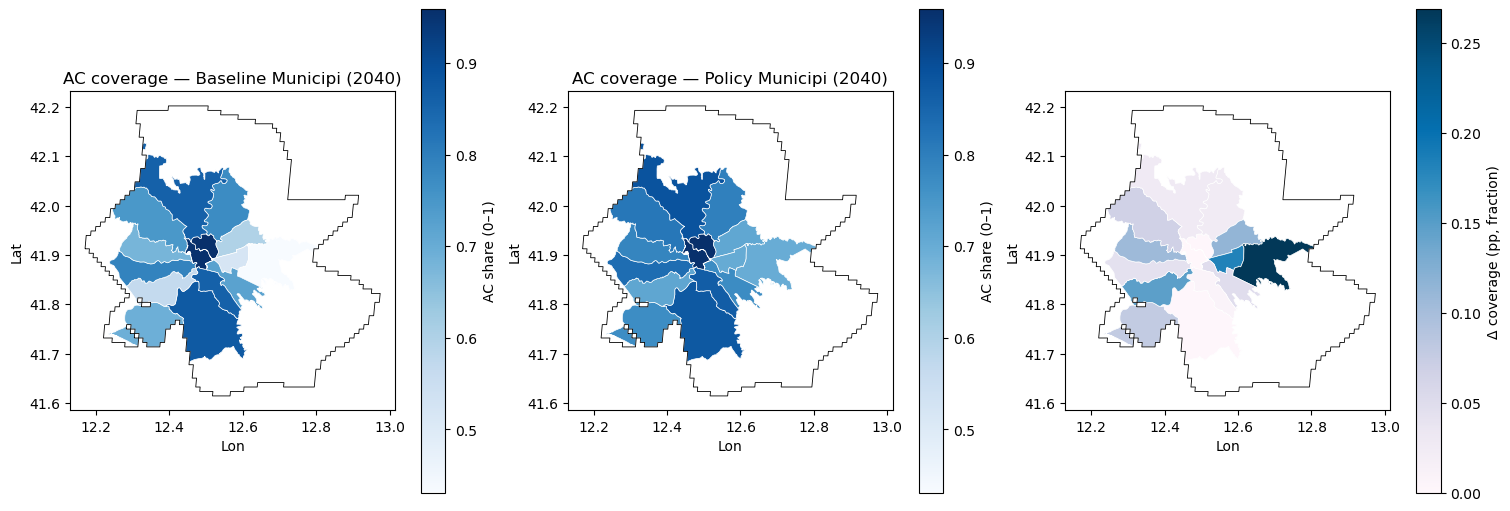


===== Municipi stats for year 2050 =====
[QA 2050] City (grid) base=0.740 vs sum-over-Municipi=0.740
[QA 2050] City (grid) pol =0.808 vs sum-over-Municipi=0.808

Top/bottom Municipi by Δ (policy - baseline), pp
    muni_id  ac_base_muni  ac_policy_muni    pop_muni  delta  delta_pp  \
6         6         0.431           0.700 129,944.773  0.269    26.892   
5         5         0.520           0.702 175,712.889  0.182    18.189   
11       11         0.567           0.715 119,803.339  0.148    14.755   
4         4         0.599           0.713 170,679.730  0.114    11.365   
13       13         0.680           0.788 130,701.854  0.107    10.711   
10       10         0.692           0.770 220,800.463  0.079     7.854   
14       14         0.747           0.814 158,462.193  0.068     6.756   
7         7         0.722           0.772 248,261.720  0.049     4.933   
12       12         0.791           0.834 131,663.471  0.043     4.324   
15       15         0.860           0.887  99,25

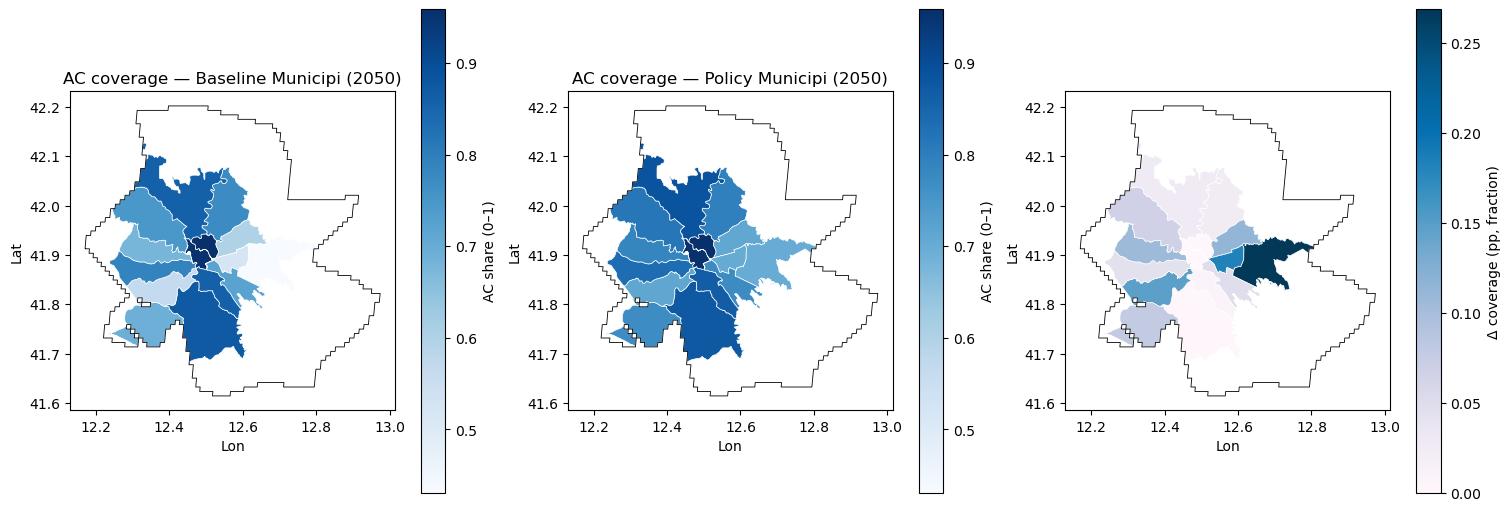

Wrote municipio coverage by year for CBA: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_muni_cov_yearly.csv


In [110]:
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.features import rasterize

# municipio label raster on the CLIMADA grid (only build once)
if "muni_on_ref" not in globals():
    regions_ref = REGION_GDF.to_crs(ref_meta["crs"])
    shapes = [(geom, int(rid)) for geom, rid in zip(regions_ref.geometry, regions_ref[REGION_ID_FIELD])]
    muni_on_ref = rasterize(
        shapes=shapes,
        out_shape=ref_data.shape,
        transform=ref_meta["transform"],
        fill=-1, dtype="int32", all_touched=False
    )

def _wavg(x, w):
    w = np.asarray(w, float); x = np.asarray(x, float)
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

# for all years
all_muni_cov = []

for YEAR_DIAG in YEARS_AC:
    print(f"\n===== Municipi stats for year {YEAR_DIAG} =====")
    k_diag = year_to_index[YEAR_DIAG]

    # year-specific baseline and policy on the grid
    coverage_base_diag   = coverage_base_3d[k_diag].astype("float32")
    coverage_policy_diag = coverage_policy_3d[k_diag].astype("float32")

    # mask where both are defined inside CAP universe
    CAP_MASK_diag = CAP_PIX & np.isfinite(coverage_base_diag) & np.isfinite(coverage_policy_diag)

    # pop-weighted aggregation of AC baseline/policy to Municipi
    mask = CAP_MASK_diag & (muni_on_ref >= 0)
    df = pd.DataFrame({
        "region_id": muni_on_ref[mask].ravel().astype(int),
        "pop":       pop_on_ref[mask].ravel().astype(float),
        "base":      coverage_base_diag[mask].ravel().astype(float),
        "policy":    coverage_policy_diag[mask].ravel().astype(float),
    })

    muni_cov = (df.groupby("region_id")
                  .apply(lambda g: pd.Series({
                      "ac_base":   _wavg(g["base"],   g["pop"]),
                      "ac_policy": _wavg(g["policy"], g["pop"]),
                      "pop_muni":  float(g["pop"].sum())
                  }))
                  .reset_index())

    muni_cov = (muni_cov
                .rename(columns={"region_id":"muni_id",
                                 "ac_base":"ac_base_muni",
                                 "ac_policy":"ac_policy_muni"})
                .assign(delta=lambda d: d["ac_policy_muni"] - d["ac_base_muni"],
                        delta_pp=lambda d: 100*(d["ac_policy_muni"] - d["ac_base_muni"])))

    # users
    dfm = df.copy()
    dfm = dfm.rename(columns={"region_id":"muni_id"})
    dfm["users_base"]   = dfm["base"]   * dfm["pop"]
    dfm["users_policy"] = dfm["policy"] * dfm["pop"]

    muni_pop   = dfm.groupby("muni_id", as_index=False)["pop"].sum().rename(columns={"pop":"pop_muni"})
    muni_users = (dfm.groupby("muni_id", as_index=False)
                    .agg(users_base=("users_base","sum"),
                         users_policy=("users_policy","sum")))

    # names
    name_cols = REGION_GDF[[REGION_ID_FIELD, REGION_NAME_FIELD]].rename(
        columns={REGION_ID_FIELD:"muni_id", REGION_NAME_FIELD:"muni_name"}
    )

    muni_cov = (muni_cov
                .merge(muni_users, on="muni_id", how="left")
                .merge(name_cols,  on="muni_id", how="left"))

    muni_cov["muni_name"] = muni_cov["muni_name"].fillna(OUTSIDE_LABEL)

    # super important step for CBA 
    muni_cov_year = muni_cov.copy()
    muni_cov_year["year"] = YEAR_DIAG

    all_muni_cov.append(
        muni_cov_year[["year",
                       "muni_id",
                       "muni_name",
                       "pop_muni",
                       "ac_base_muni",
                       "ac_policy_muni"]]
    )

    # city average from Municipi vs grid
    city_base  = popw_mean(coverage_base_diag,   CAP_MASK_diag)
    city_pol   = popw_mean(coverage_policy_diag, CAP_MASK_diag)
    agg_base   = float(np.nansum(muni_cov["ac_base_muni"]   * muni_cov["pop_muni"]) / np.nansum(muni_cov["pop_muni"]))
    agg_policy = float(np.nansum(muni_cov["ac_policy_muni"] * muni_cov["pop_muni"]) / np.nansum(muni_cov["pop_muni"]))
    print(f"[QA {YEAR_DIAG}] City (grid) base={city_base:.3f} vs sum-over-Municipi={agg_base:.3f}")
    print(f"[QA {YEAR_DIAG}] City (grid) pol ={city_pol:.3f} vs sum-over-Municipi={agg_policy:.3f}")

    # tables
    muni_only = muni_cov[muni_cov["muni_id"] > 0].copy()
    muni_only["ac_base_pct"]   = 100*muni_only["ac_base_muni"]
    muni_only["ac_policy_pct"] = 100*muni_only["ac_policy_muni"]
    muni_only["delta_pp"]      = 100*muni_only["delta"]

    print("\nTop/bottom Municipi by Δ (policy - baseline), pp")
    top = muni_only.sort_values("delta_pp", ascending=False).head(10)
    bot = muni_only.sort_values("delta_pp", ascending=True).head(10)
    if _has_display:
        display(top[["muni_id","muni_name","ac_base_pct","ac_policy_pct","delta_pp",
                     "pop_muni","users_base","users_policy"]].reset_index(drop=True))
        display(bot[["muni_id","muni_name","ac_base_pct","ac_policy_pct","delta_pp",
                     "pop_muni","users_base","users_policy"]].reset_index(drop=True))
    else:
        print(top)
        print(bot)

    # maps
    muni_map = (REGION_GDF[[REGION_ID_FIELD, REGION_NAME_FIELD, "geometry"]]
                .rename(columns={REGION_ID_FIELD:"muni_id", REGION_NAME_FIELD:"muni_name"})
                .merge(muni_only, on="muni_id", how="left"))

    vmin = float(np.nanmin(muni_map[["ac_base_muni", "ac_policy_muni"]].to_numpy()))
    vmax = float(np.nanmax(muni_map[["ac_base_muni", "ac_policy_muni"]].to_numpy()))
    dv   = float(np.nanmax(np.abs(muni_map["delta"])))

    fig, ax = plt.subplots(1, 3, figsize=(15,5), constrained_layout=True)

    fua.to_crs("EPSG:4326").boundary.plot(ax=ax[0], color="k", lw=0.6)
    muni_map.to_crs("EPSG:4326").plot(
        ax=ax[0], column="ac_base_muni", cmap="Blues",
        vmin=vmin, vmax=vmax, edgecolor="white", lw=0.5, legend=True,
        legend_kwds={"label":"AC share (0–1)"}
    )
    ax[0].set_title(f"AC coverage — Baseline {PLOT_LABEL} ({YEAR_DIAG})")

    fua.to_crs("EPSG:4326").boundary.plot(ax=ax[1], color="k", lw=0.6)
    muni_map.to_crs("EPSG:4326").plot(
        ax=ax[1], column="ac_policy_muni", cmap="Blues",
        vmin=vmin, vmax=vmax, edgecolor="white", lw=0.5, legend=True,
        legend_kwds={"label":"AC share (0–1)"}
    )
    ax[1].set_title(f"AC coverage — Policy {PLOT_LABEL} ({YEAR_DIAG})")

    fua.to_crs("EPSG:4326").boundary.plot(ax=ax[2], color="k", lw=0.6)
    muni_map.to_crs("EPSG:4326").plot(
        ax=ax[2], column="delta", cmap="PuBu",
        vmin=0.0, vmax=dv, edgecolor="white", lw=0.5, legend=True,
        legend_kwds={"label":"Δ coverage (pp, fraction)"}
    )
    for a in ax:
        a.set_xlabel("Lon"); a.set_ylabel("Lat")
    plt.show()
    
# municipio coverage by year for CBA: exporting here
if all_muni_cov:
    muni_cov_yearly = pd.concat(all_muni_cov, ignore_index=True)

    out_yearly = OUT / f"{SLUG}_muni_cov_yearly.csv"
    muni_cov_yearly.to_csv(out_yearly, index=False)
    print("Wrote municipio coverage by year for CBA:", out_yearly)

**Mortality with AC: uniform efficacy vs age-varying efficacy**

Using our scenarios efficacy again

In [111]:
EFF_MAP = globals().get("EFF_BUCKETS", None)
if not isinstance(EFF_MAP, dict) or len(EFF_MAP) == 0:
    EFF_MAP = cfg.get("efficacy", {}) if "cfg" in globals() else {}

EFF_DEFAULT = float(globals().get("EFF_DEFAULT", EFF_MAP.get("default", 0.30)))

In [112]:
print("EFF_SCENARIO =", globals().get("EFF_SCENARIO", "(not set in globals)"))
print("EFF_DEFAULT  =", EFF_DEFAULT)
print("EFF_MAP      =", {k: EFF_MAP.get(k) for k in ["<15","15-64","65+"]})

EFF_SCENARIO = high
EFF_DEFAULT  = 0.3
EFF_MAP      = {'<15': 0.3, '15-64': 0.4, '65+': 0.55}


In [113]:
REGION_GDF        = globals().get("regions", muni)
REGION_ID_FIELD   = "muni_id"
REGION_NAME_FIELD = "muni_name"
OUTSIDE_LABEL     = "Fuori Municipi (FUA)"
mask_city = CITY_MASK

_id2name = dict(
    zip(
        REGION_GDF[REGION_ID_FIELD].astype(int),
        REGION_GDF[REGION_NAME_FIELD].astype(str),
    )
)

In [114]:
mask_city = CITY_MASK

In [115]:
def _interp_mdd(I_grid, f):
    return np.interp(I_grid, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])

def _eff_for_age(age_lbl, eff_map, eff_default):
    if age_lbl in eff_map:
        return float(eff_map[age_lbl])
    for k, v in eff_map.items():
        if k == "default":
            continue
        if k in str(age_lbl):
            return float(v)
    return float(eff_default)

def deaths_with_ac(I_grid, coverage_grid, eff=0.30):
    """Uniform efficacy, one day."""
    m = mask_city & np.isfinite(I_grid)

    # fallback: city pop-weighted mean coverage for this grid
    ac_city_here = float(popw_mean(coverage_grid, CAP_MASK))

    cov = np.where(m & np.isfinite(coverage_grid), coverage_grid, ac_city_here)
    deaths = np.zeros_like(I_grid, dtype=float)
    for age_lbl, f in age_ifs.items():
        mdd = _interp_mdd(I_grid, f)
        mult = np.clip(1.0 - eff * cov, 0.0, 1.0)
        pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)
        deaths += np.where(m, pop_age * mdd * mult, 0.0)
    return deaths

def deaths_with_ac_varage(I_grid, coverage_grid, eff_by_bucket=None, eff_base=None):
    """Age-varying efficacy, one day."""
    eff_map = (eff_by_bucket or EFF_MAP).copy()
    eff_def = EFF_DEFAULT if eff_base is None else float(eff_base)

    m = mask_city & np.isfinite(I_grid)
    ac_city_here = float(popw_mean(coverage_grid, CAP_MASK))
    cov = np.where(m & np.isfinite(coverage_grid), coverage_grid, ac_city_here)
    deaths = np.zeros_like(I_grid, dtype=float)

    for age_lbl, f in age_ifs.items():
        mdd = _interp_mdd(I_grid, f)
        eff_a = _eff_for_age(age_lbl, eff_map, eff_def)
        mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)
        pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)
        deaths += np.where(m, pop_age * mdd * mult, 0.0)
    return deaths

def _row_to_grid(intensity, i_ev, grid_shape):
    row = intensity[i_ev]
    if hasattr(row, "toarray"):
        row = row.toarray()
    row = np.asarray(row, float).ravel()

    n_cells  = row.size
    expected = grid_shape[0] * grid_shape[1]

    if n_cells == expected:
        return row.reshape(grid_shape)
    if n_cells == 1:
        val = row[0]
        return np.full(grid_shape, val, dtype=float)

    raise ValueError(f"Row size {n_cells} != grid cells {expected} and != 1")

In [116]:
EFF_UNIFORM = EFF_DEFAULT
EFF_BUCKETS = EFF_MAP          # age-specific efficacies from YAML
APPLY_BASELINE_SCALING = True  # if we want scaled numbers

dates = pd.to_datetime(H.date)
sf_path = INT / f"baseline_heat_scaling_{SLUG}.csv"
if APPLY_BASELINE_SCALING:
    if not sf_path.exists():
        raise FileNotFoundError(
            f"APPLY_BASELINE_SCALING=True but missing {sf_path}. "
            "Re-run NB4 or set APPLY_BASELINE_SCALING=False."
        )
    sf = pd.read_csv(sf_path).set_index("year")

YEARS_IMPACT = YEARS_AC  # [2030, 2040, 2050]

results_city   = []
results_muni_u = []
results_muni_a = []

for year_focus in YEARS_IMPACT:
    print(f"\n===== Year {year_focus} =====")

    # ➊ Use year-specific age/pop grids if available; otherwise fallback to baseline
    age_on_ref = AGE_GRID.get(year_focus, age_on_ref_base)
    pop_on_ref = POP_GRID.get(year_focus, pop_on_ref_base)

    # picking coverage maps for that year (already time-varying)
    k = year_to_index[year_focus]
    coverage_base_y   = coverage_base_3d[k].astype(float)
    coverage_policy_y = coverage_policy_3d[k].astype(float)

    CAP_MASK = CAP_PIX & np.isfinite(coverage_base_y) & np.isfinite(coverage_policy_y)

    # hazard events for that year
    year_mask = (dates.year == year_focus)
    idx_year  = np.where(year_mask)[0]
    if idx_year.size == 0:
        print(f"  (no hazard events for {year_focus})")
        continue

    I_year = np.stack(
        [_row_to_grid(H.intensity, i_ev, ref_data.shape) for i_ev in idx_year],
        axis=0
    )

    # daily deaths, then yearly totals (uniform vs age-varying)
    def deaths_series_uniform(I_series, coverage_grid, eff):
        out = np.zeros_like(I_series, dtype=float)
        for t in range(I_series.shape[0]):
            out[t] = deaths_with_ac(I_series[t], coverage_grid, eff=eff)
        return out

    def deaths_series_agevary(I_series, coverage_grid, eff_by_bucket, eff_base=None):
        out = np.zeros_like(I_series, dtype=float)
        for t in range(I_series.shape[0]):
            out[t] = deaths_with_ac_varage(
                I_series[t], coverage_grid,
                eff_by_bucket=eff_by_bucket, eff_base=eff_base
            )
        return out

    deaths_base_uni_day   = deaths_series_uniform(I_year, coverage_base_y,   eff=EFF_UNIFORM)
    deaths_policy_uni_day = deaths_series_uniform(I_year, coverage_policy_y, eff=EFF_UNIFORM)

    deaths_base_age_day   = deaths_series_agevary(I_year, coverage_base_y,   eff_by_bucket=EFF_BUCKETS, eff_base=EFF_UNIFORM)
    deaths_policy_age_day = deaths_series_agevary(I_year, coverage_policy_y, eff_by_bucket=EFF_BUCKETS, eff_base=EFF_UNIFORM)

    deaths_base_uni   = deaths_base_uni_day.sum(axis=0)
    deaths_policy_uni = deaths_policy_uni_day.sum(axis=0)
    deaths_base_age   = deaths_base_age_day.sum(axis=0)
    deaths_policy_age = deaths_policy_age_day.sum(axis=0)

    d_avo_uni = deaths_base_uni - deaths_policy_uni
    d_avo_age = deaths_base_age - deaths_policy_age

    # optional scaling, but now for this year
    scale_fac = 1.0
    city_total_avo_uni_raw = float(np.nansum(d_avo_uni[mask_city]))
    city_total_avo_age_raw = float(np.nansum(d_avo_age[mask_city]))

    if APPLY_BASELINE_SCALING:
        if year_focus not in sf.index:
            raise ValueError(
                f"Scaling file {sf_path} has years {list(sf.index)} but not {year_focus}."
            )
        row = sf.loc[year_focus]
        age_cols = [c for c in ["<15", "15-64", "65+"] if c in row.index]
        if not age_cols:
            raise ValueError(f"No age columns <15/15-64/65+ in {sf_path} for year {year_focus}.")

        age_pops = {
            age: float(np.nansum(np.nan_to_num(age_on_ref[age], 0.0)[mask_city]))
            for age in age_cols
        }
        tot_pop = sum(age_pops.values())
        if tot_pop <= 0:
            raise ValueError("Total population on CITY_MASK is zero when computing scaling factor.")

        scale_fac = sum(row[age] * age_pops[age] for age in age_cols) / tot_pop
        d_avo_uni *= scale_fac
        d_avo_age *= scale_fac

    city_total_avo_uni = float(np.nansum(d_avo_uni[mask_city]))
    city_total_avo_age = float(np.nansum(d_avo_age[mask_city]))

    print(f"City avoided deaths (uniform eff) in {year_focus}: "
          f"raw={city_total_avo_uni_raw:.3f}, scaled={city_total_avo_uni:.3f} (factor={scale_fac:.3f})")
    print(f"City avoided deaths (age-varying eff) in {year_focus}: "
          f"raw={city_total_avo_age_raw:.3f}, scaled={city_total_avo_age:.3f} (factor={scale_fac:.3f})")

    # municipio delta AC and efficiency for this year
    df = pd.DataFrame({
        "muni_id":  muni_on_ref[CAP_MASK].ravel().astype(int),
        "pop":      pop_on_ref[CAP_MASK].ravel().astype(float),
        "base":     coverage_base_y[CAP_MASK].ravel().astype(float),
        "policy":   coverage_policy_y[CAP_MASK].ravel().astype(float),
    })

    df_muni_delta = (
        df.assign(delta=df["policy"] - df["base"])
          .groupby("muni_id", as_index=False)
          .apply(lambda g: pd.Series({
              "ΔAC_pw":       float(np.average(g["delta"], weights=g["pop"])) if g["pop"].sum() > 0 else np.nan,
              "pop_cap_mask": float(g["pop"].sum()),
          }))
          .reset_index(drop=True)
    )
    df_muni_delta["muni_name"] = df_muni_delta["muni_id"].map(_id2name)

    city_dpp_from_muni = 100.0 * (
        (df_muni_delta["ΔAC_pw"] * df_muni_delta["pop_cap_mask"]).sum()
        / df_muni_delta["pop_cap_mask"].sum()
    )
    city_dpp_from_map = 100.0 * popw_mean(coverage_policy_y - coverage_base_y, mask=CAP_MASK)
    print("City ΔAC (pp) from municipios vs map:", city_dpp_from_muni, city_dpp_from_map)

    # municipio-level avoided deaths for this year (uniform vs age-varying)

    # using same CAP_MASK: only pixels where baseline and policy coverage are defined
    mask_muni = CAP_MASK & (muni_on_ref >= 0)

    df_u = pd.DataFrame({
        "muni_id":     muni_on_ref[mask_muni].ravel().astype(int),
        "avoided":     d_avo_uni[mask_muni].ravel().astype(float),
        "deaths_base": deaths_base_uni[mask_muni].ravel().astype(float),
        "pop":         pop_on_ref[mask_muni].ravel().astype(float),
    })

    df_a = pd.DataFrame({
        "muni_id":     muni_on_ref[mask_muni].ravel().astype(int),
        "avoided":     d_avo_age[mask_muni].ravel().astype(float),
        "deaths_base": deaths_base_age[mask_muni].ravel().astype(float),
        "pop":         pop_on_ref[mask_muni].ravel().astype(float),
    })

    def _agg_muni(df):
        out = (df.groupby("muni_id", as_index=False)
                 .agg(avoided=("avoided","sum"),
                      deaths_base=("deaths_base","sum"),
                      pop_muni=("pop","sum")))
        out["avo_per_100k"] = np.where(
            out["pop_muni"] > 0,
            1e5 * out["avoided"] / out["pop_muni"],
            np.nan
        )
        return out

    df_muni_avo_uni = _agg_muni(df_u)
    df_muni_avo_age = _agg_muni(df_a)

    # attach names so merge on ["muni_id","muni_name"] works
    df_muni_avo_uni["muni_name"] = df_muni_avo_uni["muni_id"].map(_id2name)
    df_muni_avo_age["muni_name"] = df_muni_avo_age["muni_id"].map(_id2name)

    MIN_PP = 0.5
    muni_eff_uni = (df_muni_avo_uni.merge(df_muni_delta, on=["muni_id","muni_name"], how="left")
                                .assign(delta_pp=lambda d: 100*d["ΔAC_pw"],
                                        avoided_per_pp=lambda d: d["avoided"] / np.where(d["delta_pp"]>0, d["delta_pp"], np.nan),
                                        flag_small_delta=lambda d: d["delta_pp"] < MIN_PP))
    muni_eff_age = (df_muni_avo_age.merge(df_muni_delta, on=["muni_id","muni_name"], how="left")
                                .assign(delta_pp=lambda d: 100*d["ΔAC_pw"],
                                        avoided_per_pp=lambda d: d["avoided"] / np.where(d["delta_pp"]>0, d["delta_pp"], np.nan),
                                        flag_small_delta=lambda d: d["delta_pp"] < MIN_PP))

    print("Top municipios (avoided per pp uplift) — uniform EFF:")
    display(muni_eff_uni.sort_values("avoided_per_pp", ascending=False)
            [["muni_id","muni_name","avoided","avo_per_100k","delta_pp","avoided_per_pp"]]
            .head(10).reset_index(drop=True))

    print("Top municipios (avoided per pp uplift) — age-varying EFF:")
    display(muni_eff_age.sort_values("avoided_per_pp", ascending=False)
            [["muni_id","muni_name","avoided","avo_per_100k","delta_pp","avoided_per_pp"]]
            .head(10).reset_index(drop=True))

    # if we want to use later: save results
    results_city.append({
        "year": year_focus,
        "city_total_avo_uni": city_total_avo_uni,
        "city_total_avo_age": city_total_avo_age,
        "scale_fac": scale_fac,
    })
    results_muni_u.append(muni_eff_uni.assign(year=year_focus))
    results_muni_a.append(muni_eff_age.assign(year=year_focus))

# tables
results_city = pd.DataFrame(results_city).set_index("year").sort_index()
muni_eff_uni_all = pd.concat(results_muni_u, ignore_index=True)
muni_eff_age_all = pd.concat(results_muni_a, ignore_index=True)


===== Year 2030 =====
City avoided deaths (uniform eff) in 2030: raw=20.967, scaled=20.967 (factor=1.000)
City avoided deaths (age-varying eff) in 2030: raw=37.238, scaled=37.238 (factor=1.000)
City ΔAC (pp) from municipios vs map: 8.202309525325184 8.202309525325187
Top municipios (avoided per pp uplift) — uniform EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,7,Municipio Roma VII,2.260,0.910,6.789,0.333
1,9,Municipio Roma IX,0.219,0.100,0.810,0.270
2,1,Municipio Roma I,0.001,0.000,0.003,0.248
3,5,Municipio Roma V,4.105,2.336,21.039,0.195
4,8,Municipio Roma VIII,0.220,0.193,1.322,0.166
5,6,Municipio Roma VI,4.630,3.563,29.261,0.158
6,14,Municipio Roma XIV,1.310,0.827,8.443,0.155
7,0,Outside regions (FUA),0.016,0.011,0.108,0.149
8,10,Municipio Roma X,1.400,0.634,9.926,0.141
9,2,Municipio Roma II,0.025,0.015,0.175,0.141


Top municipios (avoided per pp uplift) — age-varying EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,7,Municipio Roma VII,4.020,1.619,6.789,0.592
1,9,Municipio Roma IX,0.388,0.178,0.810,0.479
2,1,Municipio Roma I,0.001,0.001,0.003,0.441
3,5,Municipio Roma V,7.294,4.151,21.039,0.347
4,8,Municipio Roma VIII,0.391,0.344,1.322,0.295
5,6,Municipio Roma VI,8.231,6.334,29.261,0.281
6,14,Municipio Roma XIV,2.326,1.468,8.443,0.275
7,0,Outside regions (FUA),0.029,0.020,0.108,0.265
8,10,Municipio Roma X,2.479,1.123,9.926,0.250
9,2,Municipio Roma II,0.044,0.027,0.175,0.250



===== Year 2040 =====
City avoided deaths (uniform eff) in 2040: raw=21.989, scaled=16.402 (factor=0.746)
City avoided deaths (age-varying eff) in 2040: raw=39.371, scaled=29.368 (factor=0.746)
City ΔAC (pp) from municipios vs map: 6.767302597848284 6.767302597848284
Top municipios (avoided per pp uplift) — uniform EFF:


...

,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,7,Municipio Roma VII,2.753,1.135,4.933,0.558
1,9,Municipio Roma IX,0.094,0.044,0.207,0.455
2,5,Municipio Roma V,6.005,3.498,18.189,0.330
3,8,Municipio Roma VIII,0.264,0.237,0.939,0.281
4,6,Municipio Roma VI,7.189,5.663,26.892,0.267
5,14,Municipio Roma XIV,1.781,1.150,6.756,0.264
6,0,Outside regions (FUA),0.024,0.017,0.095,0.248
7,2,Municipio Roma II,0.031,0.020,0.128,0.241
8,10,Municipio Roma X,1.877,0.870,7.854,0.239
9,4,Municipio Roma IV,2.704,1.621,11.365,0.238



===== Year 2050 =====
City avoided deaths (uniform eff) in 2050: raw=21.616, scaled=12.961 (factor=0.600)
City avoided deaths (age-varying eff) in 2050: raw=38.800, scaled=23.265 (factor=0.600)
City ΔAC (pp) from municipios vs map: 6.76858666575925 6.7685866657592495
Top municipios (avoided per pp uplift) — uniform EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,7,Municipio Roma VII,1.222,0.514,4.933,0.248
1,9,Municipio Roma IX,0.042,0.020,0.207,0.202
2,5,Municipio Roma V,2.655,1.577,18.189,0.146
3,8,Municipio Roma VIII,0.117,0.108,0.939,0.125
4,6,Municipio Roma VI,3.185,2.558,26.892,0.118
5,14,Municipio Roma XIV,0.785,0.517,6.756,0.116
6,0,Outside regions (FUA),0.010,0.008,0.096,0.109
7,2,Municipio Roma II,0.014,0.009,0.128,0.106
8,4,Municipio Roma IV,1.188,0.726,11.365,0.105
9,10,Municipio Roma X,0.819,0.387,7.854,0.104


Top municipios (avoided per pp uplift) — age-varying EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,7,Municipio Roma VII,2.195,0.923,4.933,0.445
1,9,Municipio Roma IX,0.075,0.036,0.207,0.362
2,5,Municipio Roma V,4.767,2.832,18.189,0.262
3,8,Municipio Roma VIII,0.211,0.193,0.939,0.224
4,6,Municipio Roma VI,5.720,4.594,26.892,0.213
5,14,Municipio Roma XIV,1.409,0.928,6.756,0.209
6,0,Outside regions (FUA),0.019,0.014,0.096,0.196
7,2,Municipio Roma II,0.024,0.016,0.128,0.190
8,4,Municipio Roma IV,2.131,1.303,11.365,0.187
9,10,Municipio Roma X,1.467,0.694,7.854,0.187


More **avoided deaths** with the age-varying efficacy

In [117]:
import numpy as np
import pandas as pd

def deaths_year_by_age(year, coverage_grid, eff_by_bucket, eff_base=None):
    """
    For a given year and AC coverage grid, return a dict:
        { age_label -> annual deaths (absolute) }
    using age-varying efficacy (eff_by_bucket) and CLIMADA hazard H.
    """
    dates = pd.to_datetime(H.date)
    mask_year = (dates.year == year)
    idx = np.where(mask_year)[0]

    if idx.size == 0:
        # no events for that year
        return {age_lbl: 0.0 for age_lbl in age_ifs.keys()}

    # where we actually model deaths
    m_city = mask_city & np.isfinite(pop_on_ref)

    # fill coverage holes with city mean (for this grid)
    cov_grid = np.where(m_city & np.isfinite(coverage_grid),
                        coverage_grid,
                        np.nan)
    # if some NaNs remain, replace by pop-weighted mean
    if np.isnan(cov_grid[m_city]).any():
        w = pop_on_ref[m_city].astype(float)
        x = np.nan_to_num(cov_grid[m_city], nan=0.0).astype(float)
        mean_cov = float(np.sum(x * w) / np.sum(w)) if w.sum() > 0 else 0.0
        cov_grid = np.where(m_city & np.isnan(cov_grid), mean_cov, cov_grid)

    out = {age_lbl: 0.0 for age_lbl in age_ifs.keys()}

    # small fix so eff_base=0.0 is not overwritten by EFF_DEFAULT
    if eff_base is None:
        eff_base_eff = EFF_DEFAULT
    else:
        eff_base_eff = eff_base

    for i_ev in idx:
        I_grid = _row_to_grid(H.intensity, i_ev, ref_data.shape)

        m = m_city & np.isfinite(I_grid)
        if not np.any(m):
            continue

        cov = np.where(m, cov_grid, 0.0)

        for age_lbl, f in age_ifs.items():
            # efficacy for this age
            eff_a = _eff_for_age(age_lbl, eff_by_bucket, eff_base_eff)

            # per-person per-day mortality at this day's temperature
            mdd = _interp_mdd(I_grid, f)

            # multiplicative protection from AC
            mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)

            pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)

            deaths_day = float(np.nansum(pop_age[m] * mdd[m] * mult[m]))
            out[age_lbl] += deaths_day

    return out

In [118]:
years = [2030, 2040, 2050]
rows = []

for year in years:
    # now varying population/exposure with time
    age_on_ref = AGE_GRID.get(year, age_on_ref_base)
    pop_on_ref = POP_GRID.get(year, pop_on_ref_base)

    k = year_to_index[year]

    cov_base_year   = coverage_base_3d[k].astype(float)
    cov_policy_year = coverage_policy_3d[k].astype(float)

    cov_generic = np.zeros_like(cov_base_year, dtype=float)

    deaths_generic = deaths_year_by_age(
        year,
        cov_generic,
        eff_by_bucket=EFF_BUCKETS,
        eff_base=0.0,          # now really means "no AC protection"
    )

    deaths_citycurrAC = deaths_year_by_age(
        year,
        cov_base_year,
        eff_by_bucket=EFF_BUCKETS,
        eff_base=EFF_UNIFORM,
    )

    deaths_policyAC = deaths_year_by_age(
        year,
        cov_policy_year,
        eff_by_bucket=EFF_BUCKETS,
        eff_base=EFF_UNIFORM,
    )

    for age_lbl in age_ifs.keys():
        d_generic = deaths_generic[age_lbl]
        d_city    = deaths_citycurrAC[age_lbl]
        d_policy  = deaths_policyAC[age_lbl]

        rows.append({
            "year": year,
            "age_group": age_lbl,
            "deaths_generic":               d_generic,
            "deaths_citycurrAC":            d_city,
            "deaths_policyAC":              d_policy,
            "avoided_citycurrAC_vs_generic": d_generic - d_city,
            "avoided_policy_vs_generic":     d_generic - d_policy,
            "avoided_policy_vs_citycurrAC":  d_city    - d_policy,
        })

avoided_by_age = pd.DataFrame(rows).sort_values(["year","age_group"])

In [119]:
for year in years:
    df_y = avoided_by_age[avoided_by_age["year"] == year]

    tot_generic = df_y["deaths_generic"].sum()
    tot_city    = df_y["deaths_citycurrAC"].sum()
    tot_policy  = df_y["deaths_policyAC"].sum()

    print(f"\nYear {year}")
    print(f"  Total deaths – generic:        {tot_generic:8.3f}")
    print(f"  Total deaths – city current AC:        {tot_city:8.3f}")
    print(f"  Total deaths – policy AC:              {tot_policy:8.3f}")
    print(f"  Avoided (city current AC vs generic):  {tot_generic - tot_city:8.3f}")
    print(f"  Avoided (policy AC vs generic):        {tot_generic - tot_policy:8.3f}")
    print(f"  Avoided (policy AC vs city current AC):{tot_city - tot_policy:8.3f}")


Year 2030
  Total deaths – generic:         888.681
  Total deaths – city current AC:         549.984
  Total deaths – policy AC:               512.746
  Avoided (city current AC vs generic):   338.697
  Avoided (policy AC vs generic):         375.935
  Avoided (policy AC vs city current AC):  37.238

Year 2040
  Total deaths – generic:        1126.836
  Total deaths – city current AC:         673.690
  Total deaths – policy AC:               634.319
  Avoided (city current AC vs generic):   453.146
  Avoided (policy AC vs generic):         492.517
  Avoided (policy AC vs city current AC):  39.371

Year 2050
  Total deaths – generic:        1108.868
  Total deaths – city current AC:         661.710
  Total deaths – policy AC:               622.910
  Avoided (city current AC vs generic):   447.158
  Avoided (policy AC vs generic):         485.958
  Avoided (policy AC vs city current AC):  38.800


In [120]:
age_order = ["<15", "15-64", "65+"]

avoided_by_age["age_group"] = pd.Categorical(
    avoided_by_age["age_group"],
    categories=age_order,
    ordered=True
)

tab_ac = (
    avoided_by_age
    .pivot(index="year", columns="age_group", values="avoided_policy_vs_citycurrAC")
    .sort_index()
)

tab_ac["overall"] = tab_ac[age_order].sum(axis=1)

print(tab_ac.round(1))

out_dir = Path(INT)
tab_ac.to_csv(out_dir / f"annual_heat_deaths_climada_avoided_AC_{SLUG}.csv")
print("Wrote:", out_dir / f"annual_heat_deaths_climada_avoided_AC_{SLUG}.csv")

age_group   <15  15-64    65+  overall
year                                  
2030      0.100  3.000 34.200   37.200
2040      0.100  2.300 37.000   39.400
2050      0.100  2.000 36.700   38.800
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/annual_heat_deaths_climada_avoided_AC_rome.csv


In [121]:
from pathlib import Path
from datetime import datetime
import json, re

out_dir = Path(INT)
out_dir.mkdir(parents=True, exist_ok=True)

sc_raw = globals().get("EFF_SCENARIO", "na")
sc = re.sub(r"[^a-zA-Z0-9._-]+", "-", str(sc_raw)).lower()
run_id = datetime.now().strftime("%Y%m%dT%H%M%S")

buckets = {k: float(v) for k, v in dict(EFF_BUCKETS).items()}

meta = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "run_id": run_id,
    "city": SLUG,
    "EFF_SCENARIO": sc_raw,
    "EFF_DEFAULT": float(EFF_DEFAULT),
    "EFF_BUCKETS": buckets,
}

# always save tab_ac
tab_latest = out_dir / f"annual_heat_deaths_climada_avoided_AC_{SLUG}.csv"
tab_ver    = out_dir / f"annual_heat_deaths_climada_avoided_AC_{SLUG}_{sc}_{run_id}.csv"
tab_ac.to_csv(tab_latest)
tab_ac.to_csv(tab_ver)

# save summary only if it exists
summary_obj = globals().get("summary", None)
if summary_obj is not None:
    sum_latest = out_dir / f"ac_policy_city_summary_{SLUG}.csv"
    sum_ver    = out_dir / f"ac_policy_city_summary_{SLUG}_{sc}_{run_id}.csv"
    summary_obj.to_csv(sum_latest, index=True)
    summary_obj.to_csv(sum_ver, index=True)
else:
    print("Note: 'summary' not defined -> skipping summary CSV saves.")

meta_path = out_dir / f"ac_run_meta_{SLUG}_{sc}_{run_id}.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print("Wrote:", tab_latest)
print("Wrote:", tab_ver)
print("Wrote:", meta_path)

Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/annual_heat_deaths_climada_avoided_AC_rome.csv
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/annual_heat_deaths_climada_avoided_AC_rome_high_20251208T164006.csv
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_run_meta_rome_high_20251208T164006.json


## NEW: Vulnerability Layer


DEATHS BY VULNERABILITY QUINTILE (with AC attenuation)
Loaded SVI grid: mean=0.572

[1] Deaths per 100k by Vulnerability Quintile (Baseline AC):
year       2030   2040   2050
quintile                     
Q1-Low   21.200 25.910 25.410
Q2       21.940 26.780 26.300
Q3       22.190 27.110 26.630
Q4       22.750 27.850 27.360
Q5-High  23.390 28.820 28.310

[2] Deaths per 100k by Vulnerability Quintile (Policy AC):
year       2030   2040   2050
quintile                     
Q1-Low   19.900 24.620 24.140
Q2       20.780 25.640 25.180
Q3       21.130 26.030 25.570
Q4       21.250 26.270 25.800
Q5-High  21.050 26.220 25.740

[3] Avoided Deaths by Quintile (Baseline → Policy):
year       2030   2040   2050
quintile                     
Q1-Low    2.150  2.150  2.110
Q2        3.710  3.630  3.580
Q3        6.820  6.940  6.840
Q4       11.030 11.580 11.400
Q5-High  13.510 15.060 14.860

[4] Disparity Ratio (Q5-High / Q1-Low) - Baseline:
  2030: 1.10x
  2040: 1.11x
  2050: 1.11x

[5] Does AC Poli

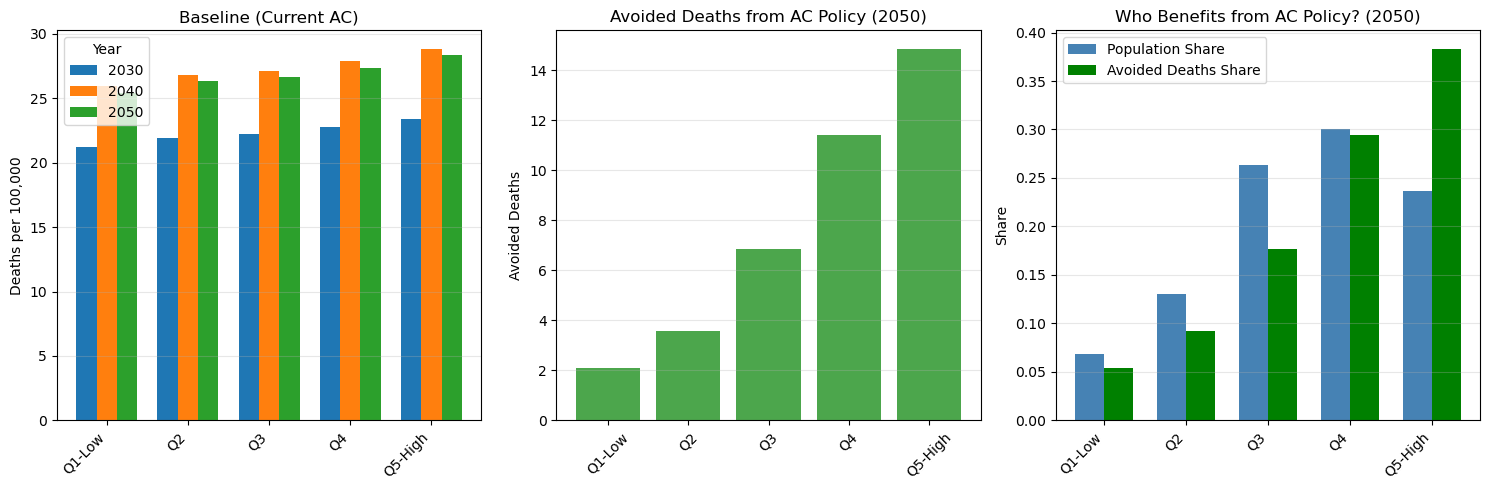

In [122]:
# Vulnerability-stratified impact analysis 
print("\n" + "="*60)
print("DEATHS BY VULNERABILITY QUINTILE (with AC attenuation)")
print("="*60)

# loading vulnerability grid
from cityheat.vulnerability_layer import load_vulnerability

try:
    vuln = load_vulnerability(INT, SLUG)
    svi_grid = vuln["svi"] # same shape as ref grid (HGT×WDT)
    HAS_VULN = True
    print(f"Loaded SVI grid: mean={np.nanmean(svi_grid):.3f}")
except FileNotFoundError:
    HAS_VULN = False
    print("No vulnerability layer found.")

if HAS_VULN:
    # creating quintile grid (same approach as exposure, but on grid)
    svi_flat = svi_grid[CITY_MASK] # only pixels inside city mask used
    quintile_edges = np.nanpercentile(svi_flat[np.isfinite(svi_flat)], [0, 20, 40, 60, 80, 100])
    # min, 20th, 40th, 60th, 80th, max of SVI across all valid city pixels
    
    # assigning each pixel to a quintile (1-5)
    quintile_grid = np.full_like(svi_grid, np.nan)
    for q in range(5):
        low, high = quintile_edges[q], quintile_edges[q+1]
        if q == 4:  # Last quintile includes upper bound
            mask_q = CITY_MASK & (svi_grid >= low) & (svi_grid <= high)
        else:
            mask_q = CITY_MASK & (svi_grid >= low) & (svi_grid < high)
        quintile_grid[mask_q] = q + 1
    
    quintile_labels = {1: "Q1-Low", 2: "Q2", 3: "Q3", 4: "Q4", 5: "Q5-High"}
    
    # modified function to return per-pixel deaths
    # computing deaths pixel-by-pixel and then sum them by SVI quintile.
    def deaths_year_by_quintile(year, coverage_grid, eff_by_bucket, eff_base=None):
        """
        Compute annual deaths per vulnerability quintile.
        Returns dict: {quintile_label -> total_deaths}
        """
        # picking hazard event from year 
        dates = pd.to_datetime(H.date)
        mask_year = (dates.year == year)
        idx = np.where(mask_year)[0]
        
        if idx.size == 0:
            return {lbl: 0.0 for lbl in quintile_labels.values()}
        
        m_city = CITY_MASK & np.isfinite(pop_on_ref)
        
        # filling coverage holes
        cov_grid = np.where(m_city & np.isfinite(coverage_grid), coverage_grid, np.nan)
        if np.isnan(cov_grid[m_city]).any():
            w = pop_on_ref[m_city].astype(float)
            x = np.nan_to_num(cov_grid[m_city], nan=0.0)
            mean_cov = float(np.sum(x * w) / np.sum(w)) if w.sum() > 0 else 0.0
            cov_grid = np.where(m_city & np.isnan(cov_grid), mean_cov, cov_grid)
        
        # accumulating deaths per pixel
        deaths_grid = np.zeros_like(svi_grid, dtype=float)
        
        for i_ev in idx:
            I_grid = _row_to_grid(H.intensity, i_ev, ref_data.shape)
            m = m_city & np.isfinite(I_grid)
            if not np.any(m):
                continue
            
            cov = np.where(m, cov_grid, 0.0)
            
            for age_lbl, f in age_ifs.items():
                eff_a = _eff_for_age(age_lbl, eff_by_bucket, eff_base or EFF_DEFAULT)
                mdd = _interp_mdd(I_grid, f)
                mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)
                pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)
                deaths_grid += np.where(m, pop_age * mdd * mult, 0.0)
        
        # summing by quintile
        result = {}
        for q, lbl in quintile_labels.items():
            mask_q = CITY_MASK & (quintile_grid == q)
            result[lbl] = float(np.nansum(deaths_grid[mask_q]))
        
        return result, deaths_grid
    
    # pop per quintile (for rates)
    pop_by_quintile = {}
    for q, lbl in quintile_labels.items():
        mask_q = CITY_MASK & (quintile_grid == q)
        pop_by_quintile[lbl] = float(np.nansum(pop_on_ref[mask_q]))
    
    # computing for all years and scenarios
    vuln_results = []
    
    for year in [2030, 2040, 2050]:
        age_on_ref = AGE_GRID.get(year, age_on_ref_base)
        pop_on_ref = POP_GRID.get(year, pop_on_ref_base)
        k = year_to_index[year]
        cov_base = coverage_base_3d[k].astype(float)
        cov_policy = coverage_policy_3d[k].astype(float)
        
        # city current AC (baseline)
        deaths_base, _ = deaths_year_by_quintile(year, cov_base, EFF_BUCKETS, EFF_UNIFORM)
        
        # policy AC
        deaths_policy, _ = deaths_year_by_quintile(year, cov_policy, EFF_BUCKETS, EFF_UNIFORM)
        
        for lbl in quintile_labels.values():
            pop = pop_by_quintile[lbl]
            vuln_results.append({
                "year": year,
                "quintile": lbl,
                "pop": pop,
                "deaths_baseline": deaths_base[lbl],
                "deaths_policy": deaths_policy[lbl],
                "avoided": deaths_base[lbl] - deaths_policy[lbl],
                "deaths_per_100k_baseline": deaths_base[lbl] / pop * 100_000 if pop > 0 else 0,
                "deaths_per_100k_policy": deaths_policy[lbl] / pop * 100_000 if pop > 0 else 0,
            })
    
    vuln_df = pd.DataFrame(vuln_results)
    
    # summary table
    print("\n[1] Deaths per 100k by Vulnerability Quintile (Baseline AC):")
    baseline_pivot = vuln_df.pivot(index="quintile", columns="year", values="deaths_per_100k_baseline")
    print(baseline_pivot.round(2))
    
    print("\n[2] Deaths per 100k by Vulnerability Quintile (Policy AC):")
    policy_pivot = vuln_df.pivot(index="quintile", columns="year", values="deaths_per_100k_policy")
    print(policy_pivot.round(2))
    
    print("\n[3] Avoided Deaths by Quintile (Baseline → Policy):")
    avoided_pivot = vuln_df.pivot(index="quintile", columns="year", values="avoided")
    print(avoided_pivot.round(2))
    
    # disparity ratio
    print("\n[4] Disparity Ratio (Q5-High / Q1-Low) - Baseline:")
    for year in [2030, 2040, 2050]:
        df_y = vuln_df[vuln_df["year"] == year]
        q5 = df_y[df_y["quintile"] == "Q5-High"]["deaths_per_100k_baseline"].values[0]
        q1 = df_y[df_y["quintile"] == "Q1-Low"]["deaths_per_100k_baseline"].values[0]
        print(f"  {year}: {q5/q1:.2f}x")
    
    # does policy reduce disparity?
    print("\n[5] Does AC Policy Reduce Disparity?")
    for year in [2030, 2040, 2050]:
        df_y = vuln_df[vuln_df["year"] == year]
        q5_base = df_y[df_y["quintile"] == "Q5-High"]["deaths_per_100k_baseline"].values[0]
        q1_base = df_y[df_y["quintile"] == "Q1-Low"]["deaths_per_100k_baseline"].values[0]
        q5_pol = df_y[df_y["quintile"] == "Q5-High"]["deaths_per_100k_policy"].values[0]
        q1_pol = df_y[df_y["quintile"] == "Q1-Low"]["deaths_per_100k_policy"].values[0]
        disp_base = q5_base / q1_base
        disp_pol = q5_pol / q1_pol
        change = "↓ reduces" if disp_pol < disp_base else "↑ increases"
        print(f"  {year}: {disp_base:.2f}x → {disp_pol:.2f}x ({change} inequality)")
    
    # saving results
    vuln_df.to_csv(INT / f"deaths_by_vulnerability_quintile_{SLUG}.csv", index=False)
    print(f"\n Saved: {INT}/deaths_by_vulnerability_quintile_{SLUG}.csv")
    
    # visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    quintiles = ["Q1-Low", "Q2", "Q3", "Q4", "Q5-High"]
    x = np.arange(len(quintiles))
    width = 0.25
    
    # panel 1: Baseline deaths by quintile
    for i, year in enumerate([2030, 2040, 2050]):
        rates = baseline_pivot.loc[quintiles, year].values
        axes[0].bar(x + i*width, rates, width, label=str(year))
    axes[0].set_xticks(x + width)
    axes[0].set_xticklabels(quintiles, rotation=45, ha='right')
    axes[0].set_ylabel("Deaths per 100,000")
    axes[0].set_title("Baseline (Current AC)")
    axes[0].legend(title="Year")
    axes[0].grid(axis='y', alpha=0.3)
    
    # panel 2: Avoided deaths by quintile (2050)
    avoided_2050 = vuln_df[vuln_df["year"] == 2050].set_index("quintile").loc[quintiles, "avoided"]
    axes[1].bar(quintiles, avoided_2050.values, color='green', alpha=0.7)
    axes[1].set_ylabel("Avoided Deaths")
    axes[1].set_title("Avoided Deaths from AC Policy (2050)")
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)
    
    # panel 3: Population share vs avoided deaths share
    pop_share = np.array([pop_by_quintile[q] for q in quintiles])
    pop_share = pop_share / pop_share.sum()
    avoided_share = avoided_2050.values / avoided_2050.sum()
    
    x = np.arange(5)
    width = 0.35
    axes[2].bar(x - width/2, pop_share, width, label="Population Share", color="steelblue")
    axes[2].bar(x + width/2, avoided_share, width, label="Avoided Deaths Share", color="green")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(quintiles, rotation=45, ha='right')
    axes[2].set_ylabel("Share")
    axes[2].set_title("Who Benefits from AC Policy? (2050)")
    axes[2].legend()
    axes[2].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUT / f"vulnerability_stratified_AC_{SLUG}.png", dpi=150)
    plt.show()

**Intepretation:**
- Row-based quibtiles : very unequal pop: 7% Q1, 30.7% Q4. More ppl live in moderate-high SVI areas than in low SVU areas. Vulnerability spatially concentrated.
- Baseline mortality by SVI quintile (row-based): baseline (current AC): deaths per 100k rise with SVI. Disparity ratio Q5/Q1: 1.11 in all years. Most vulnerable quintile about 11% higher mortality rate than least vulnrable. SVI meaningfully linked to heat-mortality.
- Effect of AC policy by SVI quintile (row-based): under AC expansion, deaths per 100k drops in all quintiles. So high SVI areas see bigger absolute drop in rate.
- Avoided deaths strongly skewed to higher SVI.
- Majority of avoided deaths occur in Q4-Q5.
- AC policy reduces risk everywhere, and reduces relative inequality btw low and high vulnerability areas.

Things to modify in my current approach: 
- Make quintiles population-weighted instead of exposure-weighted => Right now the thresholds are based on the distribution of SVI over exposure (here we put 20% of pixels in each quintile, but not 20% of population...)


DEATHS BY POP-WEIGHTED VULNERABILITY QUINTILE (with AC attenuation)

Pop-weighted SVI quintile population:
  Q1-Low: 487804
  Q2: 487833
  Q3: 487817
  Q4: 487735
  Q5-High: 487911

[1-PW] Deaths per 100k by Pop-weighted Vulnerability Quintile (Baseline AC):
year       2030   2040   2050
quintile                     
Q1-Low   26.290 27.750 25.990
Q2       26.960 28.460 26.680
Q3       26.600 28.100 26.320
Q4       28.630 30.320 28.420
Q5-High  28.260 30.090 28.190

[2-PW] Deaths per 100k by Pop-weighted Vulnerability Quintile (Policy AC):
year       2030   2040   2050
quintile                     
Q1-Low   24.800 26.490 24.820
Q2       25.700 27.370 25.660
Q3       25.140 26.840 25.150
Q4       26.270 28.150 26.390
Q5-High  25.410 27.360 25.640

[3-PW] Avoided Deaths by Pop-weighted Quintile (Baseline → Policy):
year       2030   2040   2050
quintile                     
Q1-Low    7.290  6.150  5.740
Q2        6.160  5.330  4.980
Q3        7.090  6.110  5.710
Q4       11.510 10.560  9

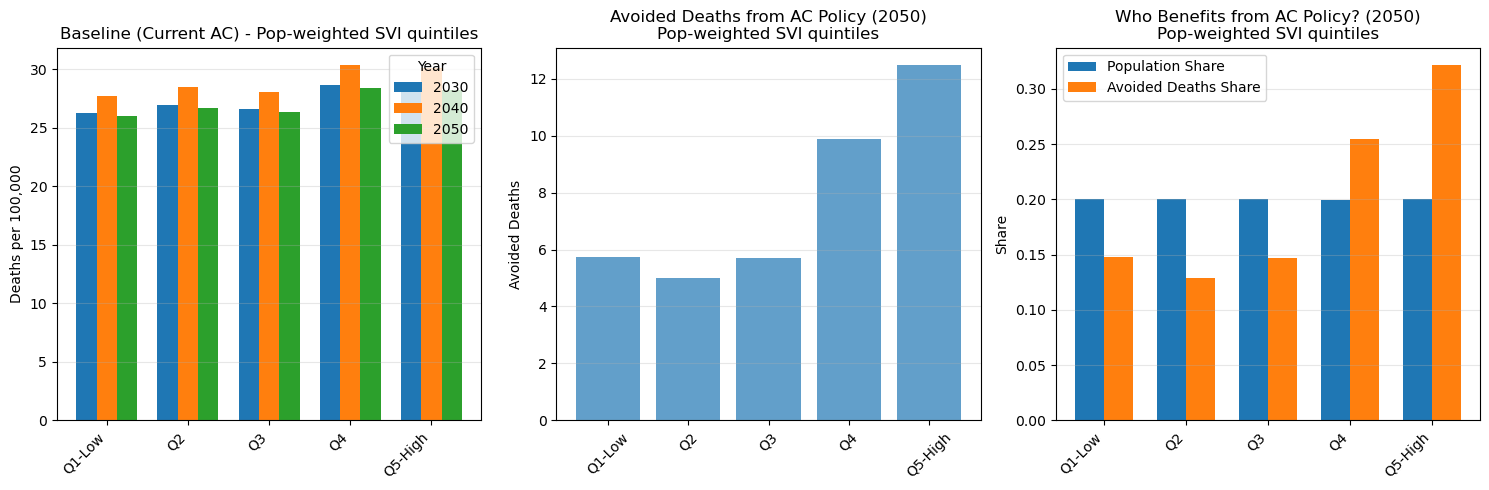

In [123]:
# Vulnerability-stratified impact analysis (pop-weighted quintiles) 
print("\n" + "="*60)
print("DEATHS BY POP-WEIGHTED VULNERABILITY QUINTILE (with AC attenuation)")
print("="*60)

if HAS_VULN:
    # building population-weighted SVI quintiles on the grid 
    valid_mask = (
        CITY_MASK &
        np.isfinite(svi_grid) &
        np.isfinite(pop_on_ref) &
        (pop_on_ref > 0)
    )

    svi_flat = svi_grid[valid_mask].astype(float)
    pop_flat = pop_on_ref[valid_mask].astype(float)

    # sort by SVI
    order = np.argsort(svi_flat)
    svi_sorted = svi_flat[order]
    pop_sorted = pop_flat[order]

    # cumulative population fraction
    cum_pop = np.cumsum(pop_sorted)
    total_pop = cum_pop[-1] if cum_pop.size > 0 else 0.0
    if total_pop == 0.0:
        raise ValueError("Total population for valid pixels is zero when building pop-weighted SVI quintiles.")

    cum_pop_frac = cum_pop / total_pop  # goes from (0,1]

    # bins / labels as in notebook 3
    labels = ["Q1-Low", "Q2", "Q3", "Q4", "Q5-High"]
    bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

    # unsort cumulative fraction back to the original valid-pixel order
    cum_pop_frac_unsorted = np.empty_like(cum_pop_frac)
    cum_pop_frac_unsorted[order] = cum_pop_frac

    # assign pop-weighted quintiles
    quintile_cat = pd.cut(
        cum_pop_frac_unsorted,
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    # map the quintile labels back onto the full ref grid
    quintile_grid_pop = np.full(pop_on_ref.size, np.nan, dtype=object)
    flat_idx_valid = np.flatnonzero(valid_mask.ravel())
    quintile_grid_pop[flat_idx_valid] = quintile_cat.astype(object)
    quintile_grid_pop = quintile_grid_pop.reshape(pop_on_ref.shape)

    # integer codes for convenience
    label_order = ["Q1-Low", "Q2", "Q3", "Q4", "Q5-High"]
    label_to_int = {lbl: i + 1 for i, lbl in enumerate(label_order)}

    quintile_grid_pop_int = np.full(pop_on_ref.shape, np.nan, dtype=float)
    for lbl, code in label_to_int.items():
        mask_lbl = (quintile_grid_pop == lbl)
        quintile_grid_pop_int[mask_lbl] = float(code)

    quintile_labels_pop = {i + 1: lbl for i, lbl in enumerate(label_order)}

    # Population per pop-weighted quintile (for rates)
    pop_by_quintile_pop = {}
    for q, lbl in quintile_labels_pop.items():
        mask_q = CITY_MASK & (quintile_grid_pop_int == q)
        pop_by_quintile_pop[lbl] = float(np.nansum(pop_on_ref[mask_q]))

    print("\nPop-weighted SVI quintile population:")
    for lbl in label_order:
        print(f"  {lbl}: {pop_by_quintile_pop[lbl]:.0f}")

    # Deaths by pop-weighted vulnerability quintile
    def deaths_year_by_pop_quintile(year, coverage_grid, eff_by_bucket, eff_base=None):
        """
        Compute annual deaths per *population-weighted* vulnerability quintile.
        Returns (dict_by_quintile_label, deaths_grid) where:
          dict_by_quintile_label: { 'Q1-Low': deaths, ..., 'Q5-High': deaths }
          deaths_grid: per-pixel deaths for that year
        """
        dates = pd.to_datetime(H.date)
        mask_year = (dates.year == year)
        idx = np.where(mask_year)[0]

        if idx.size == 0:
            return {lbl: 0.0 for lbl in quintile_labels_pop.values()}, np.zeros_like(svi_grid, dtype=float)

        m_city = CITY_MASK & np.isfinite(pop_on_ref)

        # fill coverage gaps as before
        cov_grid = np.where(m_city & np.isfinite(coverage_grid), coverage_grid, np.nan)
        if np.isnan(cov_grid[m_city]).any():
            w = pop_on_ref[m_city].astype(float)
            x = np.nan_to_num(cov_grid[m_city], nan=0.0)
            mean_cov = float(np.sum(x * w) / np.sum(w)) if w.sum() > 0 else 0.0
            cov_grid = np.where(m_city & np.isnan(cov_grid), mean_cov, cov_grid)

        deaths_grid = np.zeros_like(svi_grid, dtype=float)

        for i_ev in idx:
            I_grid = _row_to_grid(H.intensity, i_ev, ref_data.shape)
            m = m_city & np.isfinite(I_grid)
            if not np.any(m):
                continue

            cov = np.where(m, cov_grid, 0.0)

            for age_lbl, f in age_ifs.items():
                eff_a = _eff_for_age(age_lbl, eff_by_bucket, eff_base or EFF_DEFAULT)
                mdd = _interp_mdd(I_grid, f)
                mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)
                pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)
                deaths_grid += np.where(m, pop_age * mdd * mult, 0.0)

        # aggregate by pop-weighted quintiles
        result = {}
        for q, lbl in quintile_labels_pop.items():
            mask_q = CITY_MASK & (quintile_grid_pop_int == q)
            result[lbl] = float(np.nansum(deaths_grid[mask_q]))

        return result, deaths_grid

    # compute for all years / scenarios using pop-weighted quintiles
    vuln_results_pop = []

    for year in [2030, 2040, 2050]:
        k = year_to_index[year]
        cov_base = coverage_base_3d[k].astype(float)
        cov_policy = coverage_policy_3d[k].astype(float)

        deaths_base_pop, _ = deaths_year_by_pop_quintile(year, cov_base, EFF_BUCKETS, EFF_UNIFORM)
        deaths_policy_pop, _ = deaths_year_by_pop_quintile(year, cov_policy, EFF_BUCKETS, EFF_UNIFORM)

        for lbl in label_order:
            pop_q = pop_by_quintile_pop[lbl]
            vuln_results_pop.append({
                "year": year,
                "quintile": lbl,
                "pop": pop_q,
                "deaths_baseline": deaths_base_pop[lbl],
                "deaths_policy": deaths_policy_pop[lbl],
                "avoided": deaths_base_pop[lbl] - deaths_policy_pop[lbl],
                "deaths_per_100k_baseline": deaths_base_pop[lbl] / pop_q * 100_000 if pop_q > 0 else 0.0,
                "deaths_per_100k_policy": deaths_policy_pop[lbl] / pop_q * 100_000 if pop_q > 0 else 0.0,
            })

    vuln_df_pop = pd.DataFrame(vuln_results_pop)

    # summary tables (pop-weighted quintiles)
    print("\n[1-PW] Deaths per 100k by Pop-weighted Vulnerability Quintile (Baseline AC):")
    baseline_pivot_pop = vuln_df_pop.pivot(index="quintile", columns="year", values="deaths_per_100k_baseline")
    print(baseline_pivot_pop.round(2))

    print("\n[2-PW] Deaths per 100k by Pop-weighted Vulnerability Quintile (Policy AC):")
    policy_pivot_pop = vuln_df_pop.pivot(index="quintile", columns="year", values="deaths_per_100k_policy")
    print(policy_pivot_pop.round(2))

    print("\n[3-PW] Avoided Deaths by Pop-weighted Quintile (Baseline → Policy):")
    avoided_pivot_pop = vuln_df_pop.pivot(index="quintile", columns="year", values="avoided")
    print(avoided_pivot_pop.round(2))

    # disparity ratio
    print("\n[4-PW] Disparity Ratio (Q5-High / Q1-Low) - Baseline (Pop-weighted):")
    for year in [2030, 2040, 2050]:
        df_y = vuln_df_pop[vuln_df_pop["year"] == year]
        q5 = df_y[df_y["quintile"] == "Q5-High"]["deaths_per_100k_baseline"].values[0]
        q1 = df_y[df_y["quintile"] == "Q1-Low"]["deaths_per_100k_baseline"].values[0]
        print(f"  {year}: {q5/q1:.2f}x")

    print("\n[5-PW] Does AC Policy Reduce Disparity? (Pop-weighted):")
    for year in [2030, 2040, 2050]:
        df_y = vuln_df_pop[vuln_df_pop["year"] == year]
        q5_base = df_y[df_y["quintile"] == "Q5-High"]["deaths_per_100k_baseline"].values[0]
        q1_base = df_y[df_y["quintile"] == "Q1-Low"]["deaths_per_100k_baseline"].values[0]
        q5_pol = df_y[df_y["quintile"] == "Q5-High"]["deaths_per_100k_policy"].values[0]
        q1_pol = df_y[df_y["quintile"] == "Q1-Low"]["deaths_per_100k_policy"].values[0]
        disp_base = q5_base / q1_base
        disp_pol = q5_pol / q1_pol
        change = "↓ reduces" if disp_pol < disp_base else "↑ increases"
        print(f"  {year}: {disp_base:.2f}x → {disp_pol:.2f}x ({change} inequality)")

    # saving + visualization for pop-weighted quintiles
    vuln_df_pop.to_csv(INT / f"deaths_by_vulnerability_quintile_popweighted_{SLUG}.csv", index=False)
    print(f"\n Saved: {INT}/deaths_by_vulnerability_quintile_popweighted_{SLUG}.csv")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    quintiles_pw = label_order
    x = np.arange(len(quintiles_pw))
    width = 0.25

    # panel 1: Baseline deaths per 100k by pop-weighted quintile
    for i, year in enumerate([2030, 2040, 2050]):
        rates = baseline_pivot_pop.loc[quintiles_pw, year].values
        axes[0].bar(x + i*width, rates, width, label=str(year))
    axes[0].set_xticks(x + width)
    axes[0].set_xticklabels(quintiles_pw, rotation=45, ha='right')
    axes[0].set_ylabel("Deaths per 100,000")
    axes[0].set_title("Baseline (Current AC) - Pop-weighted SVI quintiles")
    axes[0].legend(title="Year")
    axes[0].grid(axis='y', alpha=0.3)

    # panel 2: Avoided deaths by pop-weighted quintile (2050)
    avoided_2050_pw = vuln_df_pop[vuln_df_pop["year"] == 2050].set_index("quintile").loc[quintiles_pw, "avoided"]
    axes[1].bar(quintiles_pw, avoided_2050_pw.values, alpha=0.7)
    axes[1].set_ylabel("Avoided Deaths")
    axes[1].set_title("Avoided Deaths from AC Policy (2050)\nPop-weighted SVI quintiles")
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)

    # panel 3: Population share vs avoided deaths share (pop-weighted quintiles)
    pop_share_pw = np.array([pop_by_quintile_pop[q] for q in quintiles_pw])
    pop_share_pw = pop_share_pw / pop_share_pw.sum()
    avoided_share_pw = avoided_2050_pw.values / avoided_2050_pw.sum()

    x2 = np.arange(5)
    width2 = 0.35
    axes[2].bar(x2 - width2/2, pop_share_pw, width2, label="Population Share")
    axes[2].bar(x2 + width2/2, avoided_share_pw, width2, label="Avoided Deaths Share")
    axes[2].set_xticks(x2)
    axes[2].set_xticklabels(quintiles_pw, rotation=45, ha='right')
    axes[2].set_ylabel("Share")
    axes[2].set_title("Who Benefits from AC Policy? (2050)\nPop-weighted SVI quintiles")
    axes[2].legend()
    axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUT / f"vulnerability_stratified_AC_popweighted_{SLUG}.png", dpi=150)
    plt.show()

else:
    print("No vulnerability layer found (HAS_VULN=False) – skipping pop-weighted analysis.")

**Interpretation** and **comparison**: 
- Baseline deaths per 100k : high-SVI people have around 8–9% higher mortality than low-SVI.
- Disparity ratio (Q5/Q1) baseline ≈ 1.08x.
- Policy deaths per 100k (pop-weighted): All quintiles benefit. The gap between Q1 and Q5 shrinks. Policy reduces inequality, just a bit more cleanly than in the row-based case because the quintiles now each hold exactly 20% of the population.
- Avoided deaths (pop-weighted): Q4 and Q5 together account for a disproportionate share of avoided deaths relative to their 40% population share. Exactly what plots show: in the right panel, the “Avoided Deaths Share” bar is highest for Q5-High, well above its 20% population share.
- Most vulnerable people are both more at risk and benefit more from the AC policy in absolute terms, and the policy slightly narrows relative mortality gaps.

- In Rome, heat-related mortality rates increase monotonically with social vulnerability. In 2050 under current AC, the most vulnerable quintile experiences around 8–11% higher mortality than the least vulnerable, depending on whether quintiles are defined by grid cells or by population. 
- Expanding AC reduces heat-related mortality for all groups but delivers larger absolute reductions in high-vulnerability areas. Among pop-weighted quintiles, the Q5-High group gains around 2.25 deaths per 100k more than Q1, and accounts for a disproportionate share of avoided deaths.
- The AC policy is mildly progressive: it reduces the Q5/Q1 mortality ratio from around 1.08–1.11 to 1.03–1.07, indicating a modest narrowing of inequalities, though substantial vulnerability gradients remain

## NEW:

For the AC feedback on temperature:
- computing how additional AC adoption modifies the impact of climate warming on heat mortality => If temperature increases by +1°C, how many extra deaths occur — and how does AC coverage change that?

In [124]:
# Marginal heat deaths per +1°C (for NB8) 
import numpy as np
import pandas as pd
import copy
from pathlib import Path

mask_city = CITY_MASK

# Hazard perturbation (+deltaT °C)
# Creating a perturbed version of CLIMADA hazard object by adding a uniform temperature shift
# (`deltaT`, typically +1°C) to all daily temperature intensities. 
# shallow copy for efficiency i.e only the intensity matrix is truly duplicated.
def hazard_add_deltaT_fast(H, deltaT: float):
    """copy hazard and add uniform +deltaT (°C) to all nonzero intensity entries."""
    H2 = copy.copy(H)
    H2.intensity = H.intensity.copy()
    H2.intensity.data = H2.intensity.data + float(deltaT)
    return H2

# Pop-weighted mean helper (we already have it somewhere, later we can delete duplicates)
def popw_mean_grid(x, mask):
    m = mask & np.isfinite(x) & np.isfinite(pop_on_ref) & (pop_on_ref > 0)
    if not np.any(m):
        return np.nan
    w = pop_on_ref[m].astype(float)
    return float(np.sum(x[m].astype(float) * w) / np.sum(w))

# Deaths by age for one year
# For each year, this function:
# Loops through all hazard events (days) in that year
# Reshapes the intensity row into a 2D grid matching reference raster
# deaths = population × mortality_dose_response(temperature) × protection_multiplier

#  For each age group, computes deaths as:
def deaths_year_by_age_from_H(H_use, year, coverage_grid, eff_by_bucket, eff_base=None):
    dates = pd.to_datetime(H_use.date)
    idx = np.where(dates.year == int(year))[0]
    if idx.size == 0:
        return {age_lbl: 0.0 for age_lbl in age_ifs.keys()}

    m_city = mask_city & np.isfinite(pop_on_ref) & (pop_on_ref > 0)

    # filling coverage holes with city pop-weighted mean 
    cov = np.array(coverage_grid, dtype=float, copy=True)
    mean_cov = popw_mean_grid(cov, m_city)
    cov = np.where(m_city & np.isfinite(cov), cov, mean_cov)

    out = {age_lbl: 0.0 for age_lbl in age_ifs.keys()}

    for i_ev in idx:
        I_grid = _row_to_grid(H_use.intensity, i_ev, ref_data.shape)
        m = m_city & np.isfinite(I_grid)
        if not np.any(m):
            continue

        cov_m = np.where(m, cov, 0.0)

        for age_lbl, f in age_ifs.items():
            eff_a = _eff_for_age(age_lbl, eff_by_bucket, eff_base if eff_base is not None else EFF_DEFAULT)
            mdd   = _interp_mdd(I_grid, f)
            mult  = np.clip(1.0 - eff_a * cov_m, 0.0, 1.0)
            pop_a = np.nan_to_num(age_on_ref[age_lbl], 0.0)

            out[age_lbl] += float(np.nansum(pop_a[m] * mdd[m] * mult[m]))

    return out

# Annual tables + marginal per +1°C

# run the same death calculation twice 
# once with original temperatures
# once with temperatures shifted by +1°C 
# then take the difference. 
# gives the marginal heat deaths per degree Celsius.
def annual_table_and_marginal_perC(H0, years, coverage_cube_or_none, eff_buckets, eff_base, deltaT=1.0):
    H1 = hazard_add_deltaT_fast(H0, deltaT)

    rows0, rows1 = [], []
    for y in years:
        age_on_ref = AGE_GRID.get(int(y), age_on_ref_base)
        pop_on_ref = POP_GRID.get(int(y), pop_on_ref_base)


        if coverage_cube_or_none is None:
            cov = np.zeros(ref_data.shape, dtype=float)  # "no AC"
        else:
            cov = coverage_cube_or_none[year_to_index[int(y)]].astype(float)

        d0 = deaths_year_by_age_from_H(H0, int(y), cov, eff_buckets, eff_base=eff_base)
        d1 = deaths_year_by_age_from_H(H1, int(y), cov, eff_buckets, eff_base=eff_base)

        rows0.append({"year": int(y), **d0})
        rows1.append({"year": int(y), **d1})

    D0 = pd.DataFrame(rows0).set_index("year").sort_index()
    D1 = pd.DataFrame(rows1).set_index("year").sort_index()
    M1 = (D1 - D0)

    for df in (D0, D1, M1):
        df["total"] = df[list(age_ifs.keys())].sum(axis=1)

    return D0, D1, M1

# running baselines
years = [int(y) for y in YEARS_AC]

# generic: eff_base=0 so mult=1 (no protection)
D0_gen, D1_gen, M1_gen = annual_table_and_marginal_perC(
    H, years, coverage_cube_or_none=None,
    eff_buckets=EFF_BUCKETS, eff_base=0.0, deltaT=1.0
)

# current AC baseline
D0_cur, D1_cur, M1_cur = annual_table_and_marginal_perC(
    H, years, coverage_cube_or_none=coverage_base_3d,
    eff_buckets=EFF_BUCKETS, eff_base=float(EFF_DEFAULT), deltaT=1.0
)

# policy AC baseline 
if "coverage_policy_3d" in globals() and coverage_policy_3d is not None:
    D0_pol, D1_pol, M1_pol = annual_table_and_marginal_perC(
        H, years, coverage_cube_or_none=coverage_policy_3d,
        eff_buckets=EFF_BUCKETS, eff_base=float(EFF_DEFAULT), deltaT=1.0
    )
else:
    D0_pol = D1_pol = M1_pol = None

display(M1_cur)

# saving for NB8
out_dir = Path(INT)
out_dir.mkdir(parents=True, exist_ok=True)

M1_gen.to_csv(out_dir / f"marginal_heat_deaths_perC_generic_{SLUG}.csv", index_label="year")
M1_cur.to_csv(out_dir / f"marginal_heat_deaths_perC_currentAC_{SLUG}.csv", index_label="year")
if M1_pol is not None:
    M1_pol.to_csv(out_dir / f"marginal_heat_deaths_perC_policyAC_{SLUG}.csv", index_label="year")

D0_cur.to_csv(out_dir / f"annual_heat_deaths_baseline_currentAC_{SLUG}.csv", index_label="year")

print("Wrote:")
print(" -", out_dir / f"marginal_heat_deaths_perC_generic_{SLUG}.csv")
print(" -", out_dir / f"marginal_heat_deaths_perC_currentAC_{SLUG}.csv")
if M1_pol is not None:
    print(" -", out_dir / f"marginal_heat_deaths_perC_policyAC_{SLUG}.csv")
print(" -", out_dir / f"annual_heat_deaths_baseline_currentAC_{SLUG}.csv")

,<15,15-64,65+,total
year,,,,
2030,0.878,21.141,292.055,314.075
2040,0.892,21.648,299.622,322.162
2050,0.875,21.006,287.571,309.452


Wrote:
 - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/marginal_heat_deaths_perC_generic_rome.csv
 - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/marginal_heat_deaths_perC_currentAC_rome.csv
 - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/marginal_heat_deaths_perC_policyAC_rome.csv
 - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/annual_heat_deaths_baseline_currentAC_rome.csv


**Shift in IF**

In [125]:
YEAR_DIAG_IF = 2030   # or 2040 / 2050
k_diag_if = year_to_index[YEAR_DIAG_IF]

coverage_base_if   = coverage_base_3d[k_diag_if].astype(float)
coverage_policy_if = coverage_policy_3d[k_diag_if].astype(float)

In [126]:
def _age_keys_from_cfg(age_ifs, cfg):
    try:
        declared = list(cfg["impact_functions"]["age_params"].keys())
        return [k for k in declared if k in age_ifs] + [k for k in age_ifs if k not in declared]
    except Exception:
        return list(age_ifs.keys())

age_keys = _age_keys_from_cfg(age_ifs, cfg)

EFF_UNIFORM = float(EFF_DEFAULT)
EFF_BUCKETS_BY_AGE = {k: float(EFF_BUCKETS.get(k, EFF_UNIFORM)) for k in age_keys}

In [127]:
# pop-weighted helper over analysis domain (CAP_MASK so coverage defined) 
DOM_MASK = CAP_MASK & np.isfinite(pop_on_ref)
w = np.where(DOM_MASK, pop_on_ref, 0.0)

def wavg_multiplier(coverage, eff):
    mult = np.clip(1.0 - eff * np.where(DOM_MASK, coverage, 0.0), 0.0, 1.0)
    return float(np.nansum(mult * w) / np.nansum(w)) if np.nansum(w) > 0 else np.nan

[Uniform eff=0.30] pop-w multiplier: baseline=0.788, policy=0.764, policy/base=0.969


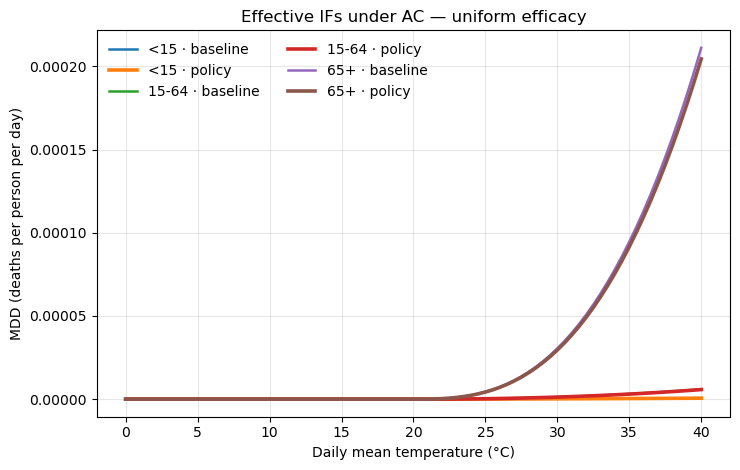

In [128]:
# uniform efficacy shift for the chosen YEAR_DIAG_IF
m_base_uni   = wavg_multiplier(coverage_base_if,   EFF_UNIFORM)
m_policy_uni = wavg_multiplier(coverage_policy_if, EFF_UNIFORM)

print(f"[Uniform eff={EFF_UNIFORM:.2f}] pop-w multiplier: "
      f"baseline={m_base_uni:.3f}, policy={m_policy_uni:.3f}, "
      f"policy/base={m_policy_uni/m_base_uni:.3f}")

plt.figure(figsize=(7.5, 4.8))
for k in age_keys:
    f = age_ifs[k]
    x = f.intensity.astype(float)
    y0 = f.mdd.astype(float)                  # per-person, per-day
    y_base   = y0 * m_base_uni
    y_policy = y0 * m_policy_uni
    plt.plot(x, y_base,   linewidth=1.8, label=f"{k} · baseline")
    plt.plot(x, y_policy, linewidth=2.6, label=f"{k} · policy")
plt.xlabel("Daily mean temperature (°C)")
plt.ylabel("MDD (deaths per person per day)")
plt.title("Effective IFs under AC — uniform efficacy")
plt.grid(alpha=0.3)
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

[Age-varying eff] pop-w multipliers:
    <15: baseline=0.788, policy=0.764, policy/base=0.969
  15-64: baseline=0.718, policy=0.685, policy/base=0.954
    65+: baseline=0.612, policy=0.567, policy/base=0.926


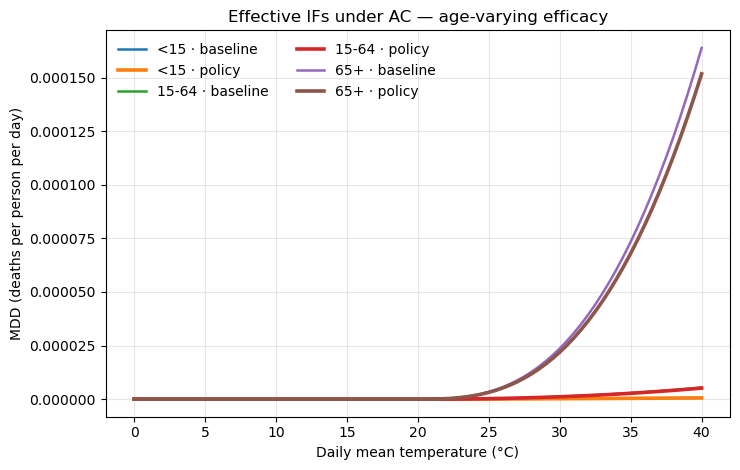

In [129]:
# age-varying efficacy shift for the chosen YEAR_DIAG_IF
m_base_age   = {age: wavg_multiplier(coverage_base_if,   EFF_BUCKETS[age]) for age in age_keys}
m_policy_age = {age: wavg_multiplier(coverage_policy_if, EFF_BUCKETS[age]) for age in age_keys}

print("[Age-varying eff] pop-w multipliers:")
for age in age_keys:
    mb, mp = m_base_age[age], m_policy_age[age]
    print(f"  {age:>5}: baseline={mb:.3f}, policy={mp:.3f}, policy/base={mp/mb:.3f}")

plt.figure(figsize=(7.5, 4.8))
for k in age_keys:
    f = age_ifs[k]
    x = f.intensity.astype(float)
    y0 = f.mdd.astype(float)                  # per-person, per-day
    y_base   = y0 * m_base_age[k]
    y_policy = y0 * m_policy_age[k]
    plt.plot(x, y_base,   linewidth=1.8, label=f"{k} · baseline")
    plt.plot(x, y_policy, linewidth=2.6, label=f"{k} · policy")
plt.xlabel("Daily mean temperature (°C)")
plt.ylabel("MDD (deaths per person per day)")
plt.title("Effective IFs under AC — age-varying efficacy")
plt.grid(alpha=0.3)
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

Conversely to before and to the CLIMADA method, here scaling is continuous, pixel by pixel => we don't create bins and discretise the cap specific scalings into a few categories => for pixel p in CAP c and age a : we multiply the impact function for the age a x by (1- efficacy of a * coverage of p) => we have one IF per CAP*age but we don't instantiate thousands of separate IF objects => we multiply by the local factor inside deaths_with_ac(...). 

> **Notes:**
> - In the uniform efficacy, all ages are scaled down by the same proportion but it looks like only 65 + moves because the 65+ IF is much larger so the % shrink is more obvious visually. 
> - In the second case - age-varying efficacy - the scale down is stronger but especially because of the fact that the efficacy for the 65+ is stronger than the uniform efficacy
> - Careful: it's the INCREMENTAL change: baseline (current AC) vs post-policy

In [130]:
import numpy as np
import pandas as pd
from pathlib import Path

age_order = ["<15", "15-64", "65+"]

# pivot avoided_by_age so we have columns per age group
tab_age = (
    avoided_by_age
    .pivot(index="year", columns="age_group", values="avoided_policy_vs_citycurrAC")
    .reindex(columns=age_order)
)

# renaming columns with explicit names 
tab_age = tab_age.rename(columns={
    "<15":   "avoided_policy_vs_citycurrAC_lt15",
    "15-64": "avoided_policy_vs_citycurrAC_15_64",
    "65+":   "avoided_policy_vs_citycurrAC_65p",
})

# total avoided (policy vs current AC) from the age table
tab_age["avoided_policy_vs_citycurrAC_total"] = (
    tab_age[[
        "avoided_policy_vs_citycurrAC_lt15",
        "avoided_policy_vs_citycurrAC_15_64",
        "avoided_policy_vs_citycurrAC_65p",
    ]].sum(axis=1)
)

# join with city-level totals (uniform and age-varying)
summary = (
    results_city
    .join(tab_age, how="left")
    .sort_index()
)

# age shares (% of total avoided, for the age-varying case)
for col_age in [
    "avoided_policy_vs_citycurrAC_lt15",
    "avoided_policy_vs_citycurrAC_15_64",
    "avoided_policy_vs_citycurrAC_65p",
]:
    share_col = col_age + "_share"
    summary[share_col] = (
        summary[col_age] / summary["avoided_policy_vs_citycurrAC_total"]
    )

# display
pd.options.display.float_format = "{:,.2f}".format
display(summary)

# save to CSV
out_summary = INT / f"ac_policy_city_summary_{SLUG}.csv"
summary.to_csv(out_summary)
print("Wrote:", out_summary)

,city_total_avo_uni,city_total_avo_age,scale_fac,avoided_policy_vs_citycurrAC_lt15,avoided_policy_vs_citycurrAC_15_64,avoided_policy_vs_citycurrAC_65p,avoided_policy_vs_citycurrAC_total,avoided_policy_vs_citycurrAC_lt15_share,avoided_policy_vs_citycurrAC_15_64_share,avoided_policy_vs_citycurrAC_65p_share
year,,,,,,,,,,
2030,20.97,37.24,1.00,0.09,3.00,34.15,37.24,0.00,0.08,0.92
2040,16.40,29.37,0.75,0.08,2.34,36.95,39.37,0.00,0.06,0.94
2050,12.96,23.27,0.60,0.08,2.03,36.69,38.80,0.00,0.05,0.95


Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_policy_city_summary_rome.csv


**Saving for later**

In [131]:
from pathlib import Path
import numpy as np

SLUG = cfg.get("slug", CITY.lower())
OUT  = Path(OUT)
INT  = Path(INT)
OUT.mkdir(parents=True, exist_ok=True)
INT.mkdir(parents=True, exist_ok=True)

# years / indexing
YEARS_AC = [int(y) for y in YEARS_AC]
year_to_index = {y: i for i, y in enumerate(YEARS_AC)}

# choosing anchor year for legacy 2D exports 
ANCHOR_YEAR = YEARS_AC[-1]              # ex 2050
k_anchor    = year_to_index[ANCHOR_YEAR]

coverage_base_3d_f   = coverage_base_3d.astype("float32")
coverage_policy_3d_f = coverage_policy_3d.astype("float32")

coverage_base_anch   = coverage_base_3d_f[k_anchor]
coverage_policy_anch = coverage_policy_3d_f[k_anchor]

# masks to store
CAP_PIX_u8  = CAP_PIX.astype("uint8") if "CAP_PIX" in globals() else None
CITY_MASK_u8 = CITY_MASK.astype("uint8")

# anchor-year “analysis mask” where both coverages exist
CAP_MASK_ANCHOR = (
    (CAP_PIX if "CAP_PIX" in globals() else CITY_MASK)
    & np.isfinite(coverage_base_anch)
    & np.isfinite(coverage_policy_anch)
).astype("uint8")

npz_path_slug   = INT / f"ac_coverage_maps_{SLUG}.npz"
npz_path_legacy = INT / "ac_coverage_maps.npz"

payload = dict(
    # full time dimension
    coverage_base_3d=coverage_base_3d_f,
    coverage_policy_3d=coverage_policy_3d_f,
    YEARS_AC=np.array(YEARS_AC, dtype="int16"),
    years=np.array(YEARS_AC, dtype="int16"),   

    # 2D anchor year (older notebooks / scripts)
    coverage_base=coverage_base_anch,
    coverage_policy=coverage_policy_anch,
    ANCHOR_YEAR=np.int16(ANCHOR_YEAR),

    # masks + geometry
    CITY_MASK=CITY_MASK_u8,
    CAP_PIX=(CAP_PIX_u8 if CAP_PIX_u8 is not None else CITY_MASK_u8),
    CAP_MASK_ANCHOR=CAP_MASK_ANCHOR,
    HGT=np.int32(HGT),
    WDT=np.int32(WDT),

    EFF_SCENARIO=np.array([str(EFF_SCENARIO)], dtype="U"),
    EFF_DEFAULT=np.array([float(EFF_DEFAULT)], dtype="float32"),
    EFF_BUCKETS_LT15=np.array([float(EFF_BUCKETS.get("<15", EFF_DEFAULT))], dtype="float32"),
    EFF_BUCKETS_15_64=np.array([float(EFF_BUCKETS.get("15-64", EFF_DEFAULT))], dtype="float32"),
    EFF_BUCKETS_65P=np.array([float(EFF_BUCKETS.get("65+", EFF_DEFAULT))], dtype="float32"),
)

np.savez_compressed(npz_path_slug, **payload)
np.savez_compressed(npz_path_legacy, **payload)

print("Wrote AC coverage cube to:", npz_path_slug)
print("Legacy alias:             ", npz_path_legacy)

# check
npz_chk = np.load(npz_path_slug)
print("Keys saved:", npz_chk.files)
print("YEARS_AC:", npz_chk["YEARS_AC"].astype(int).tolist())
print("coverage_base_3d shape:", npz_chk["coverage_base_3d"].shape)
print("coverage_policy_3d shape:", npz_chk["coverage_policy_3d"].shape)
print("anchor year:", int(npz_chk["ANCHOR_YEAR"]), "| coverage_base shape:", npz_chk["coverage_base"].shape)

Wrote AC coverage cube to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_coverage_maps_rome.npz
Legacy alias:              /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_coverage_maps.npz
Keys saved: ['coverage_base_3d', 'coverage_policy_3d', 'YEARS_AC', 'years', 'coverage_base', 'coverage_policy', 'ANCHOR_YEAR', 'CITY_MASK', 'CAP_PIX', 'CAP_MASK_ANCHOR', 'HGT', 'WDT', 'EFF_SCENARIO', 'EFF_DEFAULT', 'EFF_BUCKETS_LT15', 'EFF_BUCKETS_15_64', 'EFF_BUCKETS_65P']
YEARS_AC: [2030, 2040, 2050]
coverage_base_3d shape: (3, 301, 301)
coverage_policy_3d shape: (3, 301, 301)
anchor year: 2050 | coverage_base shape: (301, 301)


In [132]:
meta_cov = ref_meta.copy()
meta_cov.update({"dtype": "float32", "count": 1, "nodata": np.float32(np.nan)})

for y in YEARS_AC:
    k = year_to_index[y]
    with rio.open(INT / f"ac_coverage_base_{SLUG}_{y}.tif", "w", **meta_cov) as dst:
        dst.write(coverage_base_3d[k].astype("float32"), 1)
    with rio.open(INT / f"ac_coverage_policy_{SLUG}_{y}.tif", "w", **meta_cov) as dst:
        dst.write(coverage_policy_3d[k].astype("float32"), 1)

print("Wrote per-year AC GeoTIFFs for", YEARS_AC)

Wrote per-year AC GeoTIFFs for [2030, 2040, 2050]


In [133]:
# CAP grid on ref
np.savez_compressed(INT / f"cap_on_ref_{SLUG}.npz", cap_on_ref=cap_on_ref.astype("int32"))

meta_cap = ref_meta.copy()
meta_cap.update({"dtype": "int32", "count": 1, "nodata": 0})
with rio.open(INT / f"cap_on_ref_{SLUG}.tif", "w", **meta_cap) as dst:
    dst.write(cap_on_ref.astype("int32"), 1)
print("✓ Wrote CAP rasters:", INT / f"cap_on_ref_{SLUG}.npz", INT / f"cap_on_ref_{SLUG}.tif")

# LUT + vector layers
(cap_ref[["cap_id","cap5"]]
 .astype({"cap_id": int, "cap5": str})
 .drop_duplicates()
 .to_csv(OUT / f"{SLUG}_cap_lut.csv", index=False))

gpkg_cap = OUT / f"{SLUG}_cap.gpkg"
cap_ref.to_file(gpkg_cap, layer="cap", driver="GPKG")

cap_4326 = cap_4326.set_crs("EPSG:4326", allow_override=True)
cap_4326.to_file(gpkg_cap, layer="cap_wgs84", driver="GPKG")
cap_4326.to_file(OUT / f"{SLUG}_cap_wgs84.geojson", driver="GeoJSON")
(cap_4326[["cap_id","cap5"]].astype({"cap_id": int, "cap5": str})
         .drop_duplicates()
         .to_csv(OUT / f"{SLUG}_cap_wgs84_lut.csv", index=False))

print("Wrote CAP lookups and vectors to:", gpkg_cap)

✓ Wrote CAP rasters: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/cap_on_ref_rome.npz /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/cap_on_ref_rome.tif
Wrote CAP lookups and vectors to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_cap.gpkg


In [134]:
eff_path = INT / f"ac_eff_buckets_{SLUG}.json"

eff_src = globals().get("EFF_BUCKETS", None)
if not isinstance(eff_src, dict) or len(eff_src) == 0:
    eff_src = cfg.get("efficacy", {}) or {}

default_eff = float(globals().get("EFF_DEFAULT", eff_src.get("default", 0.30)))
buckets_to_save = {k: float(eff_src.get(k, default_eff)) for k in ["<15","15-64","65+"]}

with open(eff_path, "w") as fh:
    json.dump(buckets_to_save, fh, indent=2)

print("Wrote AC efficacy buckets to:", eff_path)

Wrote AC efficacy buckets to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_eff_buckets_rome.json


In [135]:
# ensure muni_on_ref exists on the current ref grid
needs_raster = (
    ("muni_on_ref" not in globals())
    or (muni_on_ref.shape != ref_data.shape)
)

if needs_raster:
    muni_gpkg = OUT / f"{SLUG}_regions.gpkg"
    assert muni_gpkg.exists(), f"Missing {muni_gpkg} – run NB5 for {CITY} first."

    muni_gdf = gpd.read_file(muni_gpkg, layer="muni")
    regions_ref = muni_gdf.to_crs(ref_meta["crs"])

    from rasterio.features import rasterize
    shapes = [
        (geom, int(mid))
        for geom, mid in zip(regions_ref.geometry, regions_ref["muni_id"])
    ]

    muni_on_ref = rasterize(
        shapes=shapes,
        out_shape=ref_data.shape,
        transform=ref_meta["transform"],
        fill=0, dtype="int32",
        all_touched=False,
    )

    muni_names = muni_gdf[["muni_id", "muni_name"]].drop_duplicates()

# municipio-level AC coverage for the anchor year (ex: 2050)
valid = (
    np.isfinite(pop_on_ref)
    & np.isfinite(coverage_base_anch)
    & np.isfinite(coverage_policy_anch)
    & (muni_on_ref > 0)
)

df_muni_cov = pd.DataFrame({
    "muni_id":  muni_on_ref[valid].ravel().astype(int),
    "pop":      pop_on_ref[valid].ravel().astype(float),
    "users_b": (coverage_base_anch[valid]   * pop_on_ref[valid]).ravel().astype(float),
    "users_p": (coverage_policy_anch[valid] * pop_on_ref[valid]).ravel().astype(float),
})

grp = (
    df_muni_cov.groupby("muni_id", as_index=False)
               .agg(pop_muni=("pop", "sum"),
                    users_b=("users_b", "sum"),
                    users_p=("users_p", "sum"))
)

muni_cov = grp.assign(
    ac_base_muni   = np.where(grp["pop_muni"] > 0, grp["users_b"] / grp["pop_muni"], np.nan),
    ac_policy_muni = np.where(grp["pop_muni"] > 0, grp["users_p"] / grp["pop_muni"], np.nan),
)[["muni_id", "pop_muni", "ac_base_muni", "ac_policy_muni"]]

if "muni_names" in globals():
    muni_cov = (
        muni_cov.merge(muni_names, on="muni_id", how="left")
                [["muni_id", "muni_name", "pop_muni", "ac_base_muni", "ac_policy_muni"]]
    )

out_csv = OUT / f"muni_cov_{SLUG}.csv"
muni_cov.to_csv(out_csv, index=False)
print("✓ Wrote municipio coverage table:", out_csv)

# municipio ids on ref grid raster
muni_tif = OUT / f"muni_on_ref_{SLUG}.tif"
meta_muni = ref_meta.copy()
meta_muni.update({"dtype": "int32", "count": 1, "nodata": 0})

with rio.open(muni_tif, "w", **meta_muni) as dst:
    dst.write(muni_on_ref.astype("int32"), 1)

print("Wrote municipio raster:", muni_tif)

✓ Wrote municipio coverage table: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/muni_cov_rome.csv
Wrote municipio raster: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/muni_on_ref_rome.tif


In [136]:
# municipio ids on ref grid
with rio.open(OUT / f"muni_on_ref_{SLUG}.tif", "w", **{**ref_meta, "dtype":"int32","count":1,"nodata":0} ) as dst:
    dst.write(muni_on_ref.astype("int32"), 1)

In [137]:
import pandas as pd, numpy as np
from pathlib import Path

rows = []
for y in YEARS_AC:
    k = year_to_index[int(y)]
    base = coverage_base_3d[k].astype(float)
    pol  = coverage_policy_3d[k].astype(float)

    m = CAP_PIX & np.isfinite(pop_on_ref) & (pop_on_ref > 0) & np.isfinite(base) & np.isfinite(pol)

    pop_city = float(np.nansum(pop_on_ref[m]))
    users_base = float(np.nansum(base[m] * pop_on_ref[m]))
    users_pol  = float(np.nansum(pol[m]  * pop_on_ref[m]))

    rows.append({
        "year": int(y),
        "pop_city": pop_city,
        "ac_share_base_popw": users_base / pop_city if pop_city > 0 else np.nan,
        "ac_share_pol_popw":  users_pol  / pop_city if pop_city > 0 else np.nan,
        "users_base": users_base,
        "users_policy": users_pol,
        "added_users": users_pol - users_base,
    })

ac_users_yearly = pd.DataFrame(rows).sort_values("year")
out = Path(INT) / f"ac_users_yearly_{SLUG}.csv"
ac_users_yearly.to_csv(out, index=False)
print("Wrote:", out)

Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_users_yearly_rome.csv
